# 1. Introduction to the Dataset And The Aim of the EDA

Phishing is a social engineering technique where attackers use deceptive websites to steal sensitive information such as login credentials and financial data.

The dataset provided consists of website features extracted by the data engineering team, representing both phishing (label 0) and legitimate (label 1) websites. These features include:

- Structural/URL Features: LineOfCode, LargestLineLength, NoOfURLRedirect, etc.
- Content/Domain Features: NoOfImage, NoOfSelfRef, DomainAgeMonths, etc.
- Metadata/Technical Features: Industry, Hosting Provider, Robots, etc.

The primary objective of this EDA is to uncover the underlying patterns that distinguish malicious websites from legitimate ones. This analysis serves as the foundation for the end-to-end machine learning pipeline by achieving the following goals:

- Assess Data Quality: Identify and document potential "contaminated" or synthetic data issues, including outliers and missing values, as noted in the problem statement.
- Feature Characterization: Understand the distributions of both numerical and categorical attributes to inform preprocessing steps like scaling or encoding.
- Identify Key Predictors: Use statistical correlations and visualizations to determine which features (e.g., NoOfURLRedirect or DomainAgeMonths) contribute most significantly to phishing detection.
- Justify Model Selection: Use the insights gained here to justify the choice of at least three machine learning models.

1.1 Library Setup and Data Loading

In [18]:
# Base libraries
import time
import datetime
import os
import sqlite3

# Scientific libraries
import numpy as np
import pandas as pd
from empiricaldist import Cdf, Pmf

# Visual libraries
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import missingno as msno  # Visualize missing values

# Helper libraries
from tqdm.notebook import tqdm, trange
from colorama import Fore, Back, Style
import warnings
warnings.filterwarnings('ignore')

# Visual setup
import matplotlib.ticker as ticker
plt.style.use('ggplot')
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['figure.figsize'] = [12, 9]
rcParams['font.size'] = 16
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
custom_colors = ['#74a09e','#86c1b2','#98e2c6','#f3c969','#f2a553', '#d96548', '#c14953']
sns.set_palette(custom_colors)
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

# Pandas options
pd.set_option('max_colwidth', 40)
pd.options.display.max_columns = None  # Possible to limit
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Seed value for numpy.random
np.random.seed(42)

In [7]:
# Prevents truncation
pd.set_option('display.max_columns', None)

# Connect the database
conn = sqlite3.connect(r"./data/phishing.db")
phishing_df = pd.read_sql_query("SELECT * from phishing_data", conn)
phishing_df.head()
phishing_df.tail()

,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
0,0,NaN,9965,0,0,2,1,48,172,170,1,1,Fashion,DreamHost,98,0
1,1,769.0,9507,0,0,0,4,25,55,78,1,1,Fashion,AWS,31,1
2,2,720.0,2550,0,0,0,2,-31,94,13,0,1,Education,Google Cloud,26,1
3,3,198.0,869,0,0,0,0,0,0,2,0,0,Unknown,DreamHost,2,1
4,4,972.0,2807,0,0,0,2,6,83,51,0,1,Education,GoDaddy,43,1


,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
10495,10495,NaN,43,0,0,0,0,0,0,0,0,0,Education,InfinityFree,10,0
10496,10496,20.0,207,1,1,0,0,0,0,0,0,0,Unknown,000webhost,9,0
10497,10497,NaN,129,0,0,0,0,0,2,0,0,0,eCommerce,Hostinger,2,0
10498,10498,2.0,40,0,0,0,0,0,0,0,0,0,eCommerce,000webhost,32,1
10499,10499,1502.0,17094,0,0,0,1,158,114,112,1,1,Non-profit,Google Cloud,31,1


# Basic Exploration and Data Cleaning
The goal of this section is to get a feel for the data and identify potential data quality issues.

The 15 attributes in our dataset can be categorised into 2 main categories:
1. Numerical Features (10)

These represent measurable quantities. We will analyze these for central tendency (mean/median), dispersion (variance/outliers), and skewness.
- LineOfCode: Number of lines of code.
- LargestLineLength: Longest line of code.
- NoOfURLRedirect: Count of redirects from the website.
- NoOfSelfRedirect: Count of self-redirects from the website.
- NoOfPopup: Number of pop-ups identified.
- NoOfiFrame: Number of iFrames used.
- NoOfImage: Total images found.
- NoOfSelfRef: Links within the same domain.
- NoOfExternalRef: Links to external websites.
- DomainAgeMonths: Months since domain creation.

2. Categorical Features (5)

These represent qualitative characteristics. We will analyze these using frequency counts and mode to understand the distribution of website types.
- Robots: Presence of a robots.txt file.
- IsResponsive: Mobile-responsiveness of the site.
- Industry: The sector the website belongs to.
- Hosting Provider: The service provider hosting the site.
- label: The target variable (0 = Phishing, 1 = Legitimate).

2.1 Basic Exploration

In [10]:
phishing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         10500 non-null  int64  
 1   LineOfCode         8145 non-null   float64
 2   LargestLineLength  10500 non-null  int64  
 3   NoOfURLRedirect    10500 non-null  int64  
 4   NoOfSelfRedirect   10500 non-null  int64  
 5   NoOfPopup          10500 non-null  int64  
 6   NoOfiFrame         10500 non-null  int64  
 7   NoOfImage          10500 non-null  int64  
 8   NoOfSelfRef        10500 non-null  int64  
 9   NoOfExternalRef    10500 non-null  int64  
 10  Robots             10500 non-null  int64  
 11  IsResponsive       10500 non-null  int64  
 12  Industry           10500 non-null  object 
 13  HostingProvider    10500 non-null  object 
 14  DomainAgeMonths    10500 non-null  int64  
 15  label              10500 non-null  int64  
dtypes: float64(1), int64(1

In [9]:
phishing_df.isnull().sum()

Unnamed: 0              0
LineOfCode           2355
LargestLineLength       0
NoOfURLRedirect         0
NoOfSelfRedirect        0
NoOfPopup               0
NoOfiFrame              0
NoOfImage               0
NoOfSelfRef             0
NoOfExternalRef         0
Robots                  0
IsResponsive            0
Industry                0
HostingProvider         0
DomainAgeMonths         0
label                   0
dtype: int64

<Axes: >

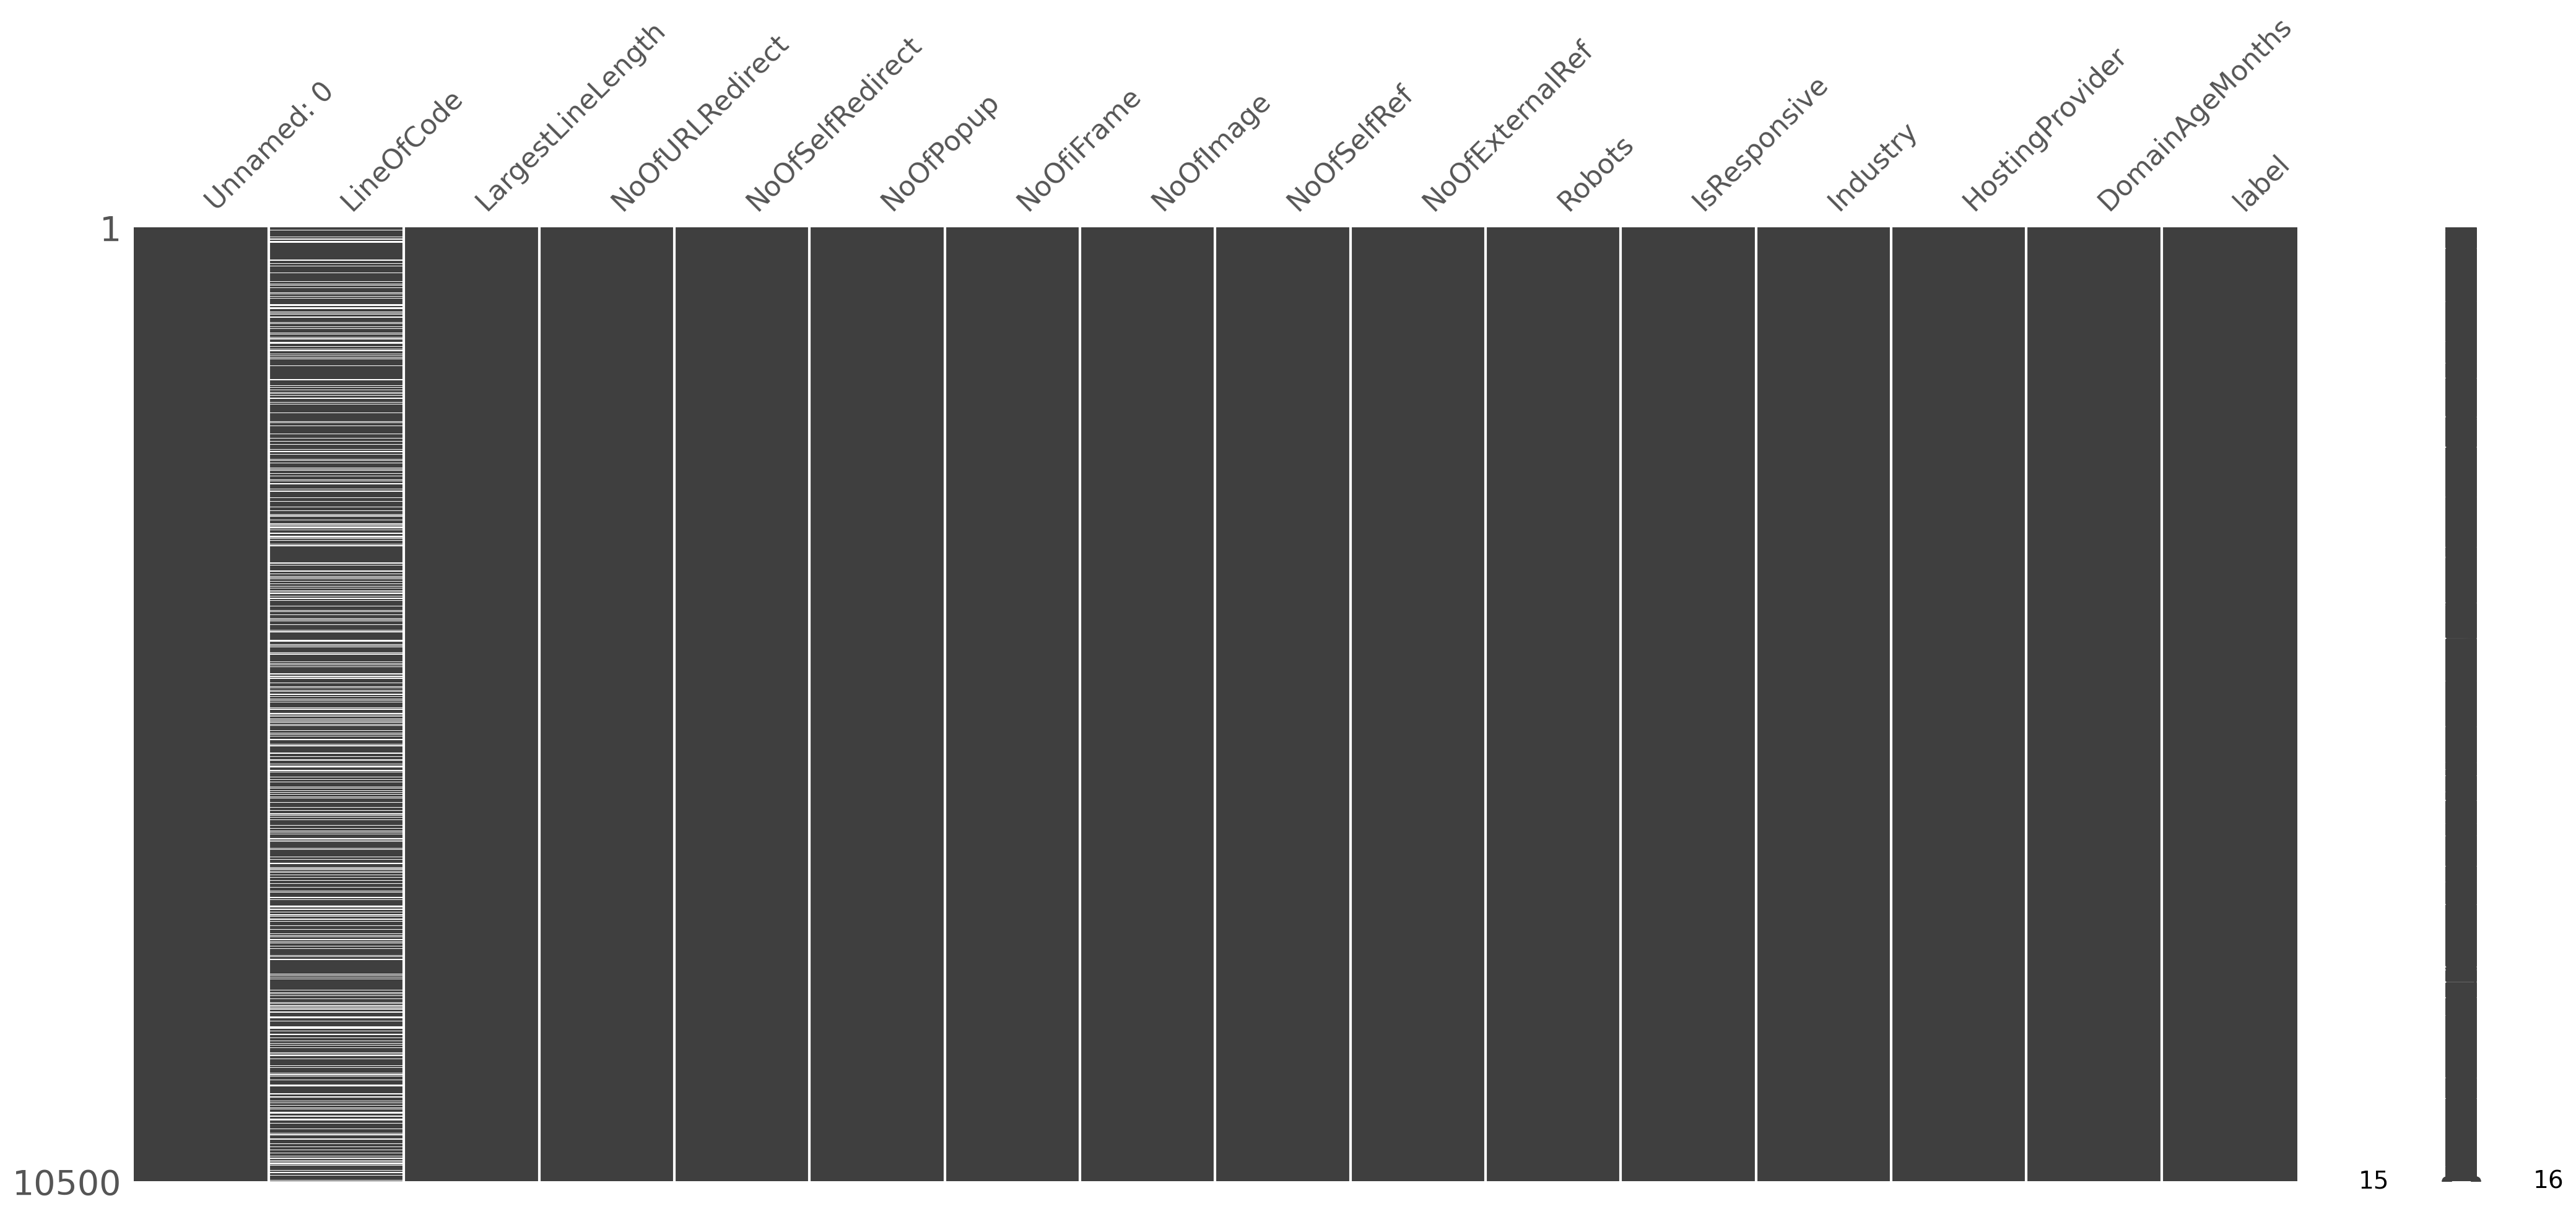

In [8]:
msno.matrix(phishing_df)

We notice two major problems with the data. First, there are 15 attributes but 16 columns. The extra column, which contains the row indices, is an artifact that can introduce noise if the model predicts labels based off it instead of learning actual meaningful patterns.

Second, the LineOfCode variable as 2355 missing values.

We will keep these issues in mind when we perform data cleaning later.

In [11]:
# include categorical data as well (not just numerical)
phishing_df.describe(include='all')

,Unnamed: 0,LineOfCode,LargestLineLength,NoOfURLRedirect,NoOfSelfRedirect,NoOfPopup,NoOfiFrame,NoOfImage,NoOfSelfRef,NoOfExternalRef,Robots,IsResponsive,Industry,HostingProvider,DomainAgeMonths,label
count,10500.000000,8145.000000,1.050000e+04,10500.000000,10500.000000,10500.000000,10500.000000,1.050000e+04,10500.00000,10500.000000,10500.000000,10500.000000,10500,10500,10500.000000,10500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,13,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eCommerce,Unknown Provider,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2521,1177,NaN,NaN
mean,5249.500000,1376.952363,1.119796e+04,0.136762,0.038476,0.227524,1.668381,3.252675e+02,68.54219,51.152476,0.262952,0.623619,NaN,NaN,33.170190,0.550381
std,3031.233247,5751.557001,9.416898e+04,0.343612,0.192352,5.700292,5.016302,3.089686e+04,316.67927,204.902781,0.440258,0.484500,NaN,NaN,32.698117,0.497479
min,0.000000,2.000000,2.200000e+01,0.000000,0.000000,0.000000,0.000000,-3.500000e+01,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000
25%,2624.750000,88.000000,1.807500e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.00000,1.000000,0.000000,0.000000,NaN,NaN,5.000000,0.000000
50%,5249.500000,620.000000,1.087500e+03,0.000000,0.000000,0.000000,0.000000,5.000000e+00,12.00000,10.000000,0.000000,1.000000,NaN,NaN,24.000000,1.000000
75%,7874.250000,1452.000000,8.047000e+03,0.000000,0.000000,0.000000,1.000000,2.500000e+01,87.00000,55.000000,1.000000,1.000000,NaN,NaN,52.000000,1.000000


Next, we analyse the statistical distribution of the dataset.

Categorical: We notice that ecommerce is the most frequent category and appeared 2521 times. Unknown hosting providers are also the most common with a count of 1177. These could be important features to pay attention to. Also these are strings and will require encoding.

Numerical: LineOfCode seems heavily skewed to the right, and contains extreme outliers with a range that spans from 2 to ~400000.
No. of external ref and No. of self ref also show massive outliers, the mean is 51.5 and 68.5 but the max can go up to 12353 and 26596 respectively.
We can therefore consider tree-based models which are more robust to such distributions.
We also notice that No. of images has a negative min value, which will have to be clipped to a floor of zero.

In [12]:
phishing_df['label'].value_counts(normalize=True)

label
1    0.550381
0    0.449619
Name: proportion, dtype: float64

We then verify that the classes are balanced so we will not need to perform SMOTE.

2.2 Data Cleaning

It is a good practice to begin with the easiest issues.

In [13]:
# remove the row index artifact to prevent data leakage
phishing_df = phishing_df.drop(columns=['Unnamed: 0'])

In [14]:
# rectify 'contaminated' negative values 
phishing_df['NoOfImage'] = phishing_df['NoOfImage'].clip(lower=0)

In [16]:
# due to extreme outliers and skewness, impute with the median instead of the mean
loc_median = phishing_df['LineOfCode'].median()
phishing_df['LineOfCode'] = phishing_df['LineOfCode'].fillna(loc_median)

In [47]:
# remove leading/trailing spaces and standardize casing
phishing_df['Industry'] = phishing_df['Industry'].str.strip()
phishing_df['Industry'] = phishing_df['Industry'].str.title()
phishing_df['HostingProvider'] = phishing_df['HostingProvider'].str.strip().str.title()

In [15]:
# group any missing categorical data into a single 'Unknown' category so that encoding will work correctly later
phishing_df['HostingProvider'] = phishing_df['HostingProvider'].fillna('Unknown Provider')
phishing_df['Industry'] = phishing_df['Industry'].fillna('Unknown')

In [17]:
# shuffle the dataset to ensure labels are distributed randomly
# this prevents the model from learning based on the database order
phishing_df = phishing_df.sample(frac=1, random_state=42).reset_index(drop=True)

<Axes: >

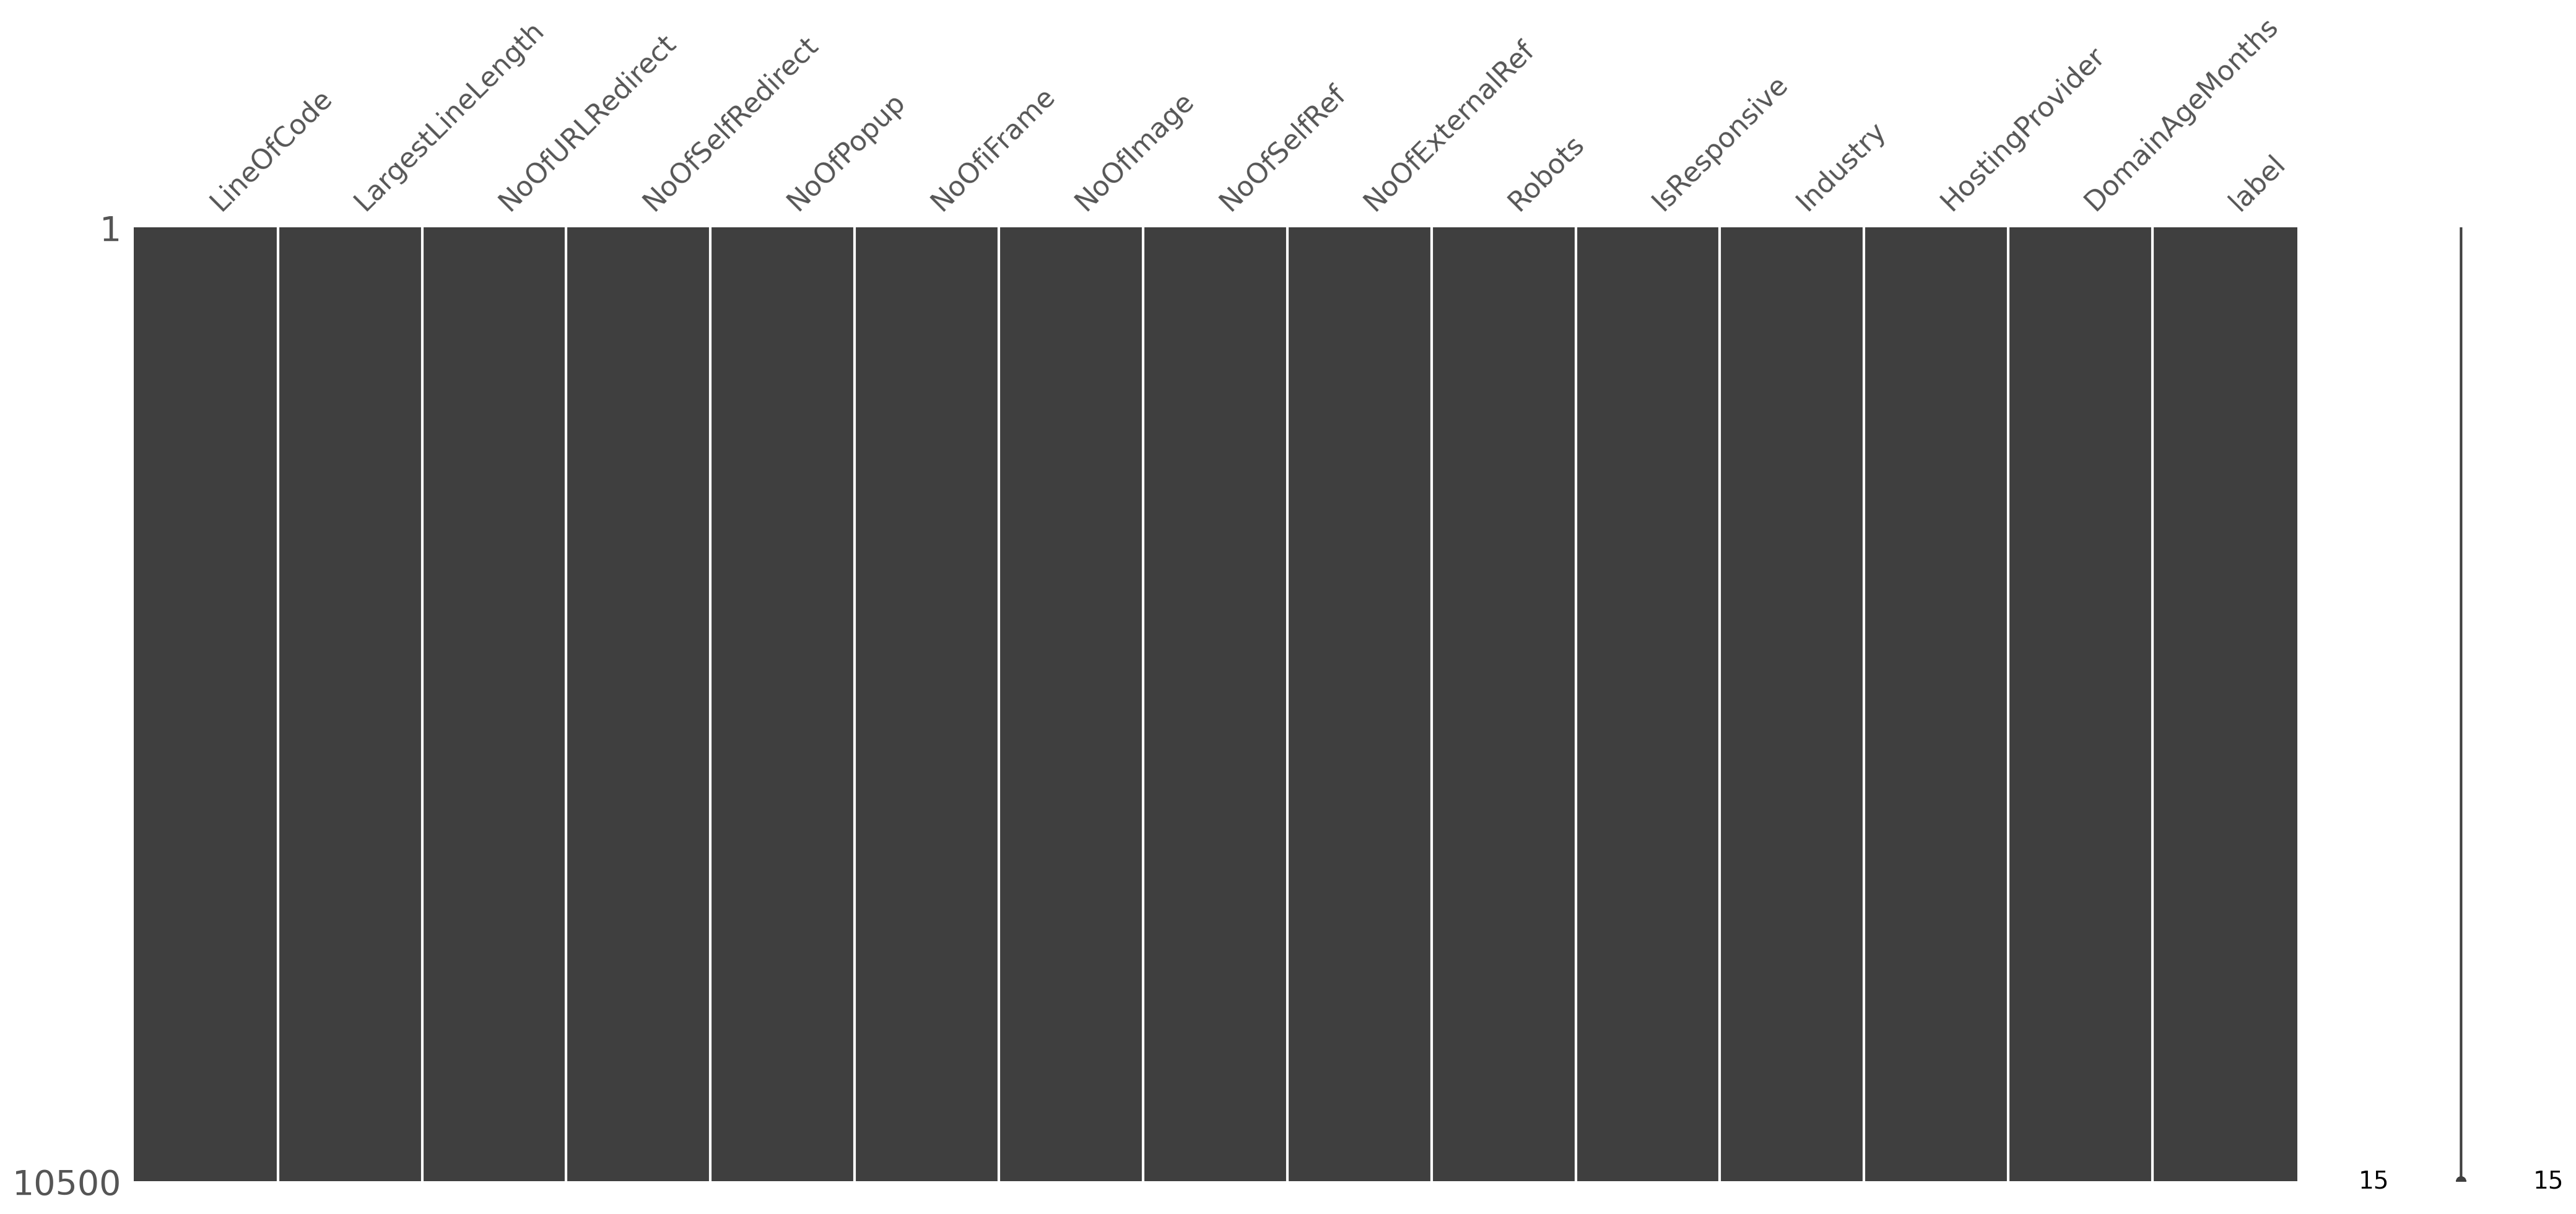

In [19]:
msno.matrix(phishing_df)

This visualization represents the rectified and complete dataset following the data cleaning phase. The matrix confirms that the Unnamed: 0 index artifact has been successfully removed (reducing the feature count to 15) and that median imputation has resolved the 22% missing data gap in the LineOfCode attribute. The dataset now exhibits 100% density across all 10,500 entries, making it suitable for high-fidelity model training.

# 3. Univariate Exploration

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='count', ylabel='Industry'>

Text(0.5, 1.0, 'Full Frequency Distribution of Industry')

Text(0.5, 0, 'Count')

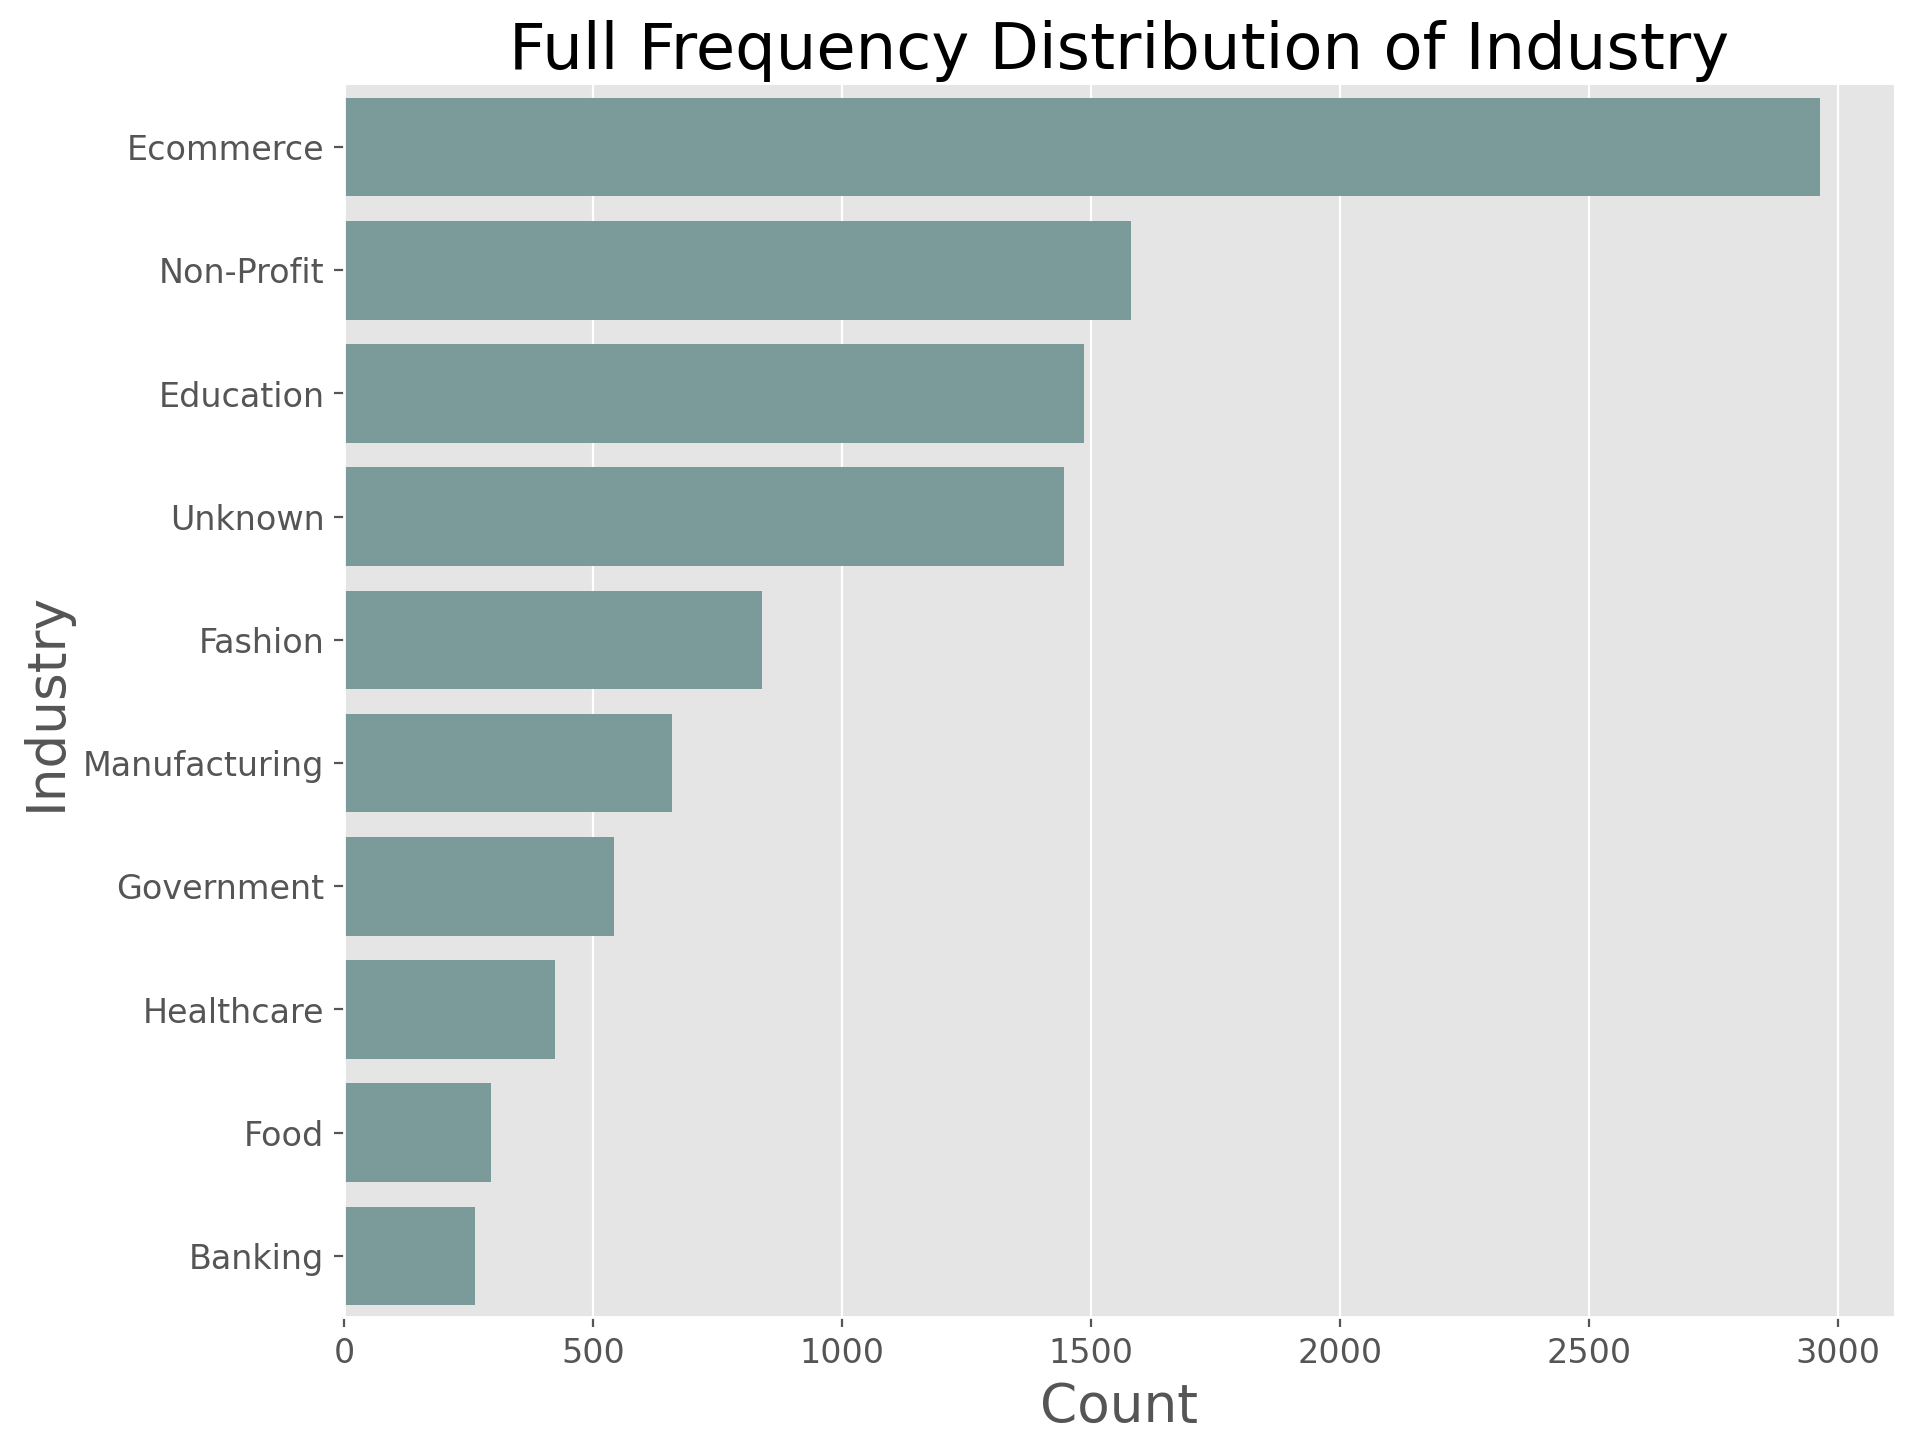

The feature 'Industry' contains 10 unique categories.
Top 3 Analysis:
  1. Ecommerce: 2965 occurrences (28.2%)
  2. Non-Profit: 1580 occurrences (15.0%)
  3. Education: 1486 occurrences (14.2%)


<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='count', ylabel='HostingProvider'>

Text(0.5, 1.0, 'Full Frequency Distribution of HostingProvider')

Text(0.5, 0, 'Count')

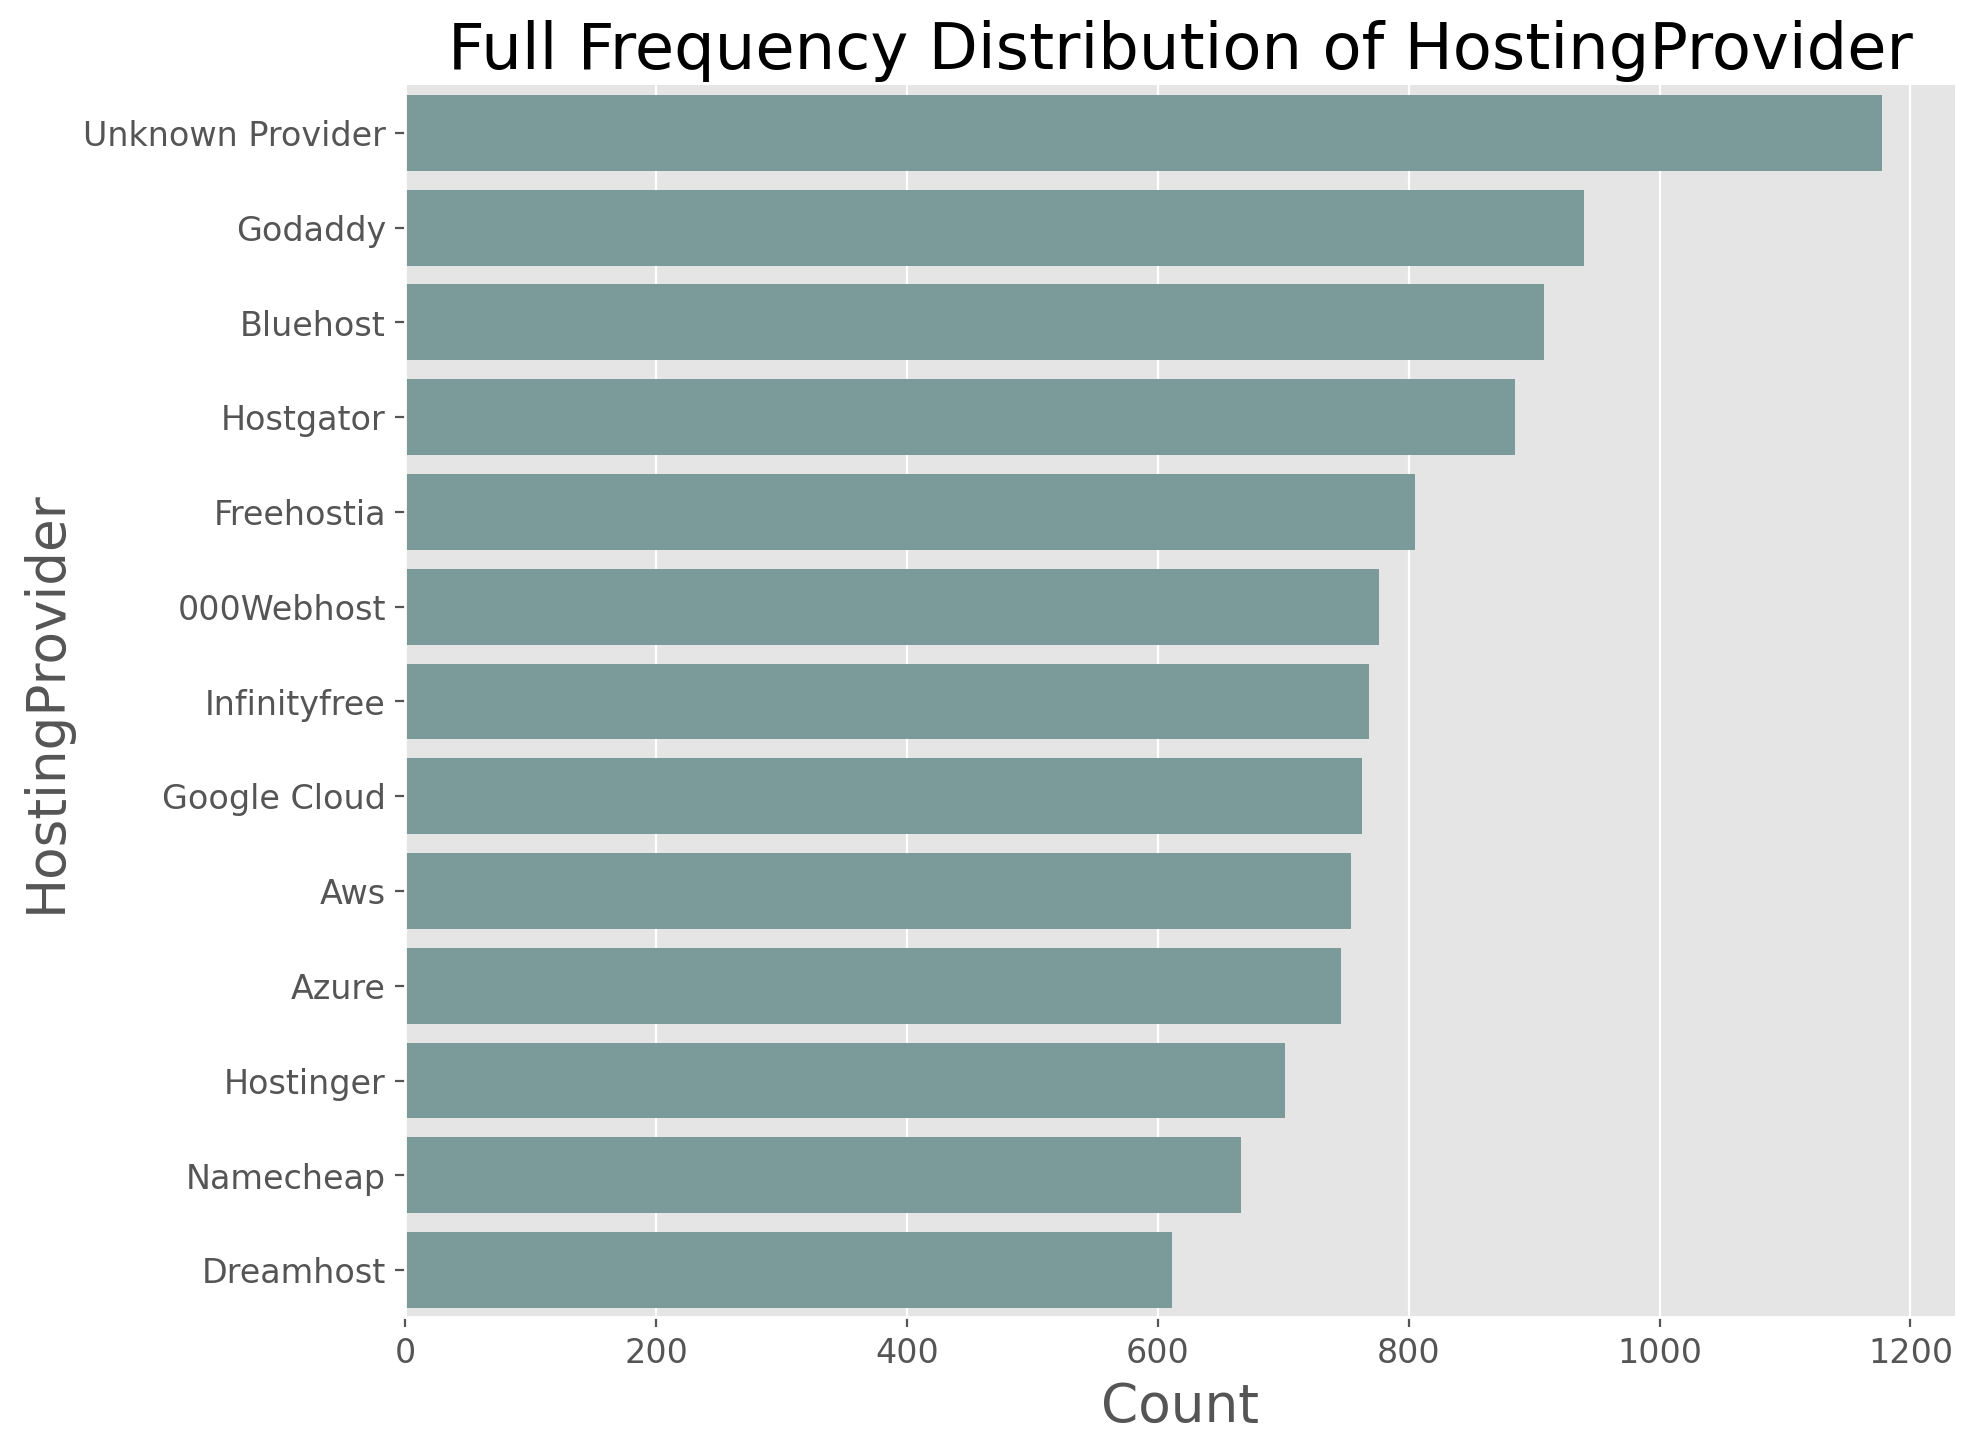

The feature 'HostingProvider' contains 13 unique categories.
Top 3 Analysis:
  1. Unknown Provider: 1177 occurrences (11.2%)
  2. Godaddy: 940 occurrences (9.0%)
  3. Bluehost: 908 occurrences (8.6%)


In [48]:
 # visualize Top Categories for Industry and HostingProvider 
cat_cols = ['Industry', 'HostingProvider']

for col in cat_cols:
    plt.figure(figsize=(10, 8))
    counts = phishing_df[col].value_counts()
    top_categories = counts.index.tolist()
    top_values = counts.values.tolist()
    sns.countplot(data=phishing_df, y=col, order=top_categories)
    plt.title(f'Full Frequency Distribution of {col}')
    plt.xlabel('Count')
    plt.show()

    print(f"The feature '{col}' contains {phishing_df[col].nunique()} unique categories.")
    
    print("Top 3 Analysis:")
    for i in range(min(3, len(top_categories))):
        percentage = (top_values[i] / len(phishing_df)) * 100
        print(f"  {i+1}. {top_categories[i]}: {top_values[i]} occurrences ({percentage:.1f}%)")

Ecommerce, Non-profit and Education sites are the most frequent categories represented in the sample. This suggests that phishing campaigns frequently impersonate these high-trust or high-transaction industries to increase the likelihood of victim engagement.
Also, the high number of occurrences in the unknown provider category highlights a lack of metadata for a large portion of the sample. This absence of verified hosting information is a known characteristic of temporary or low-cost phishing infrastructure and can be useful for the model.

<Figure size 1200x500 with 0 Axes>

<Axes: >

<Axes: xlabel='Robots', ylabel='count'>

Text(0.5, 1.0, 'Binary Distribution: Robots')

The majority of websites in the dataset have a value of 0 for 'Robots' (73.7%).


<Axes: >

<Axes: xlabel='IsResponsive', ylabel='count'>

Text(0.5, 1.0, 'Binary Distribution: IsResponsive')

The majority of websites in the dataset have a value of 1 for 'IsResponsive' (62.4%).


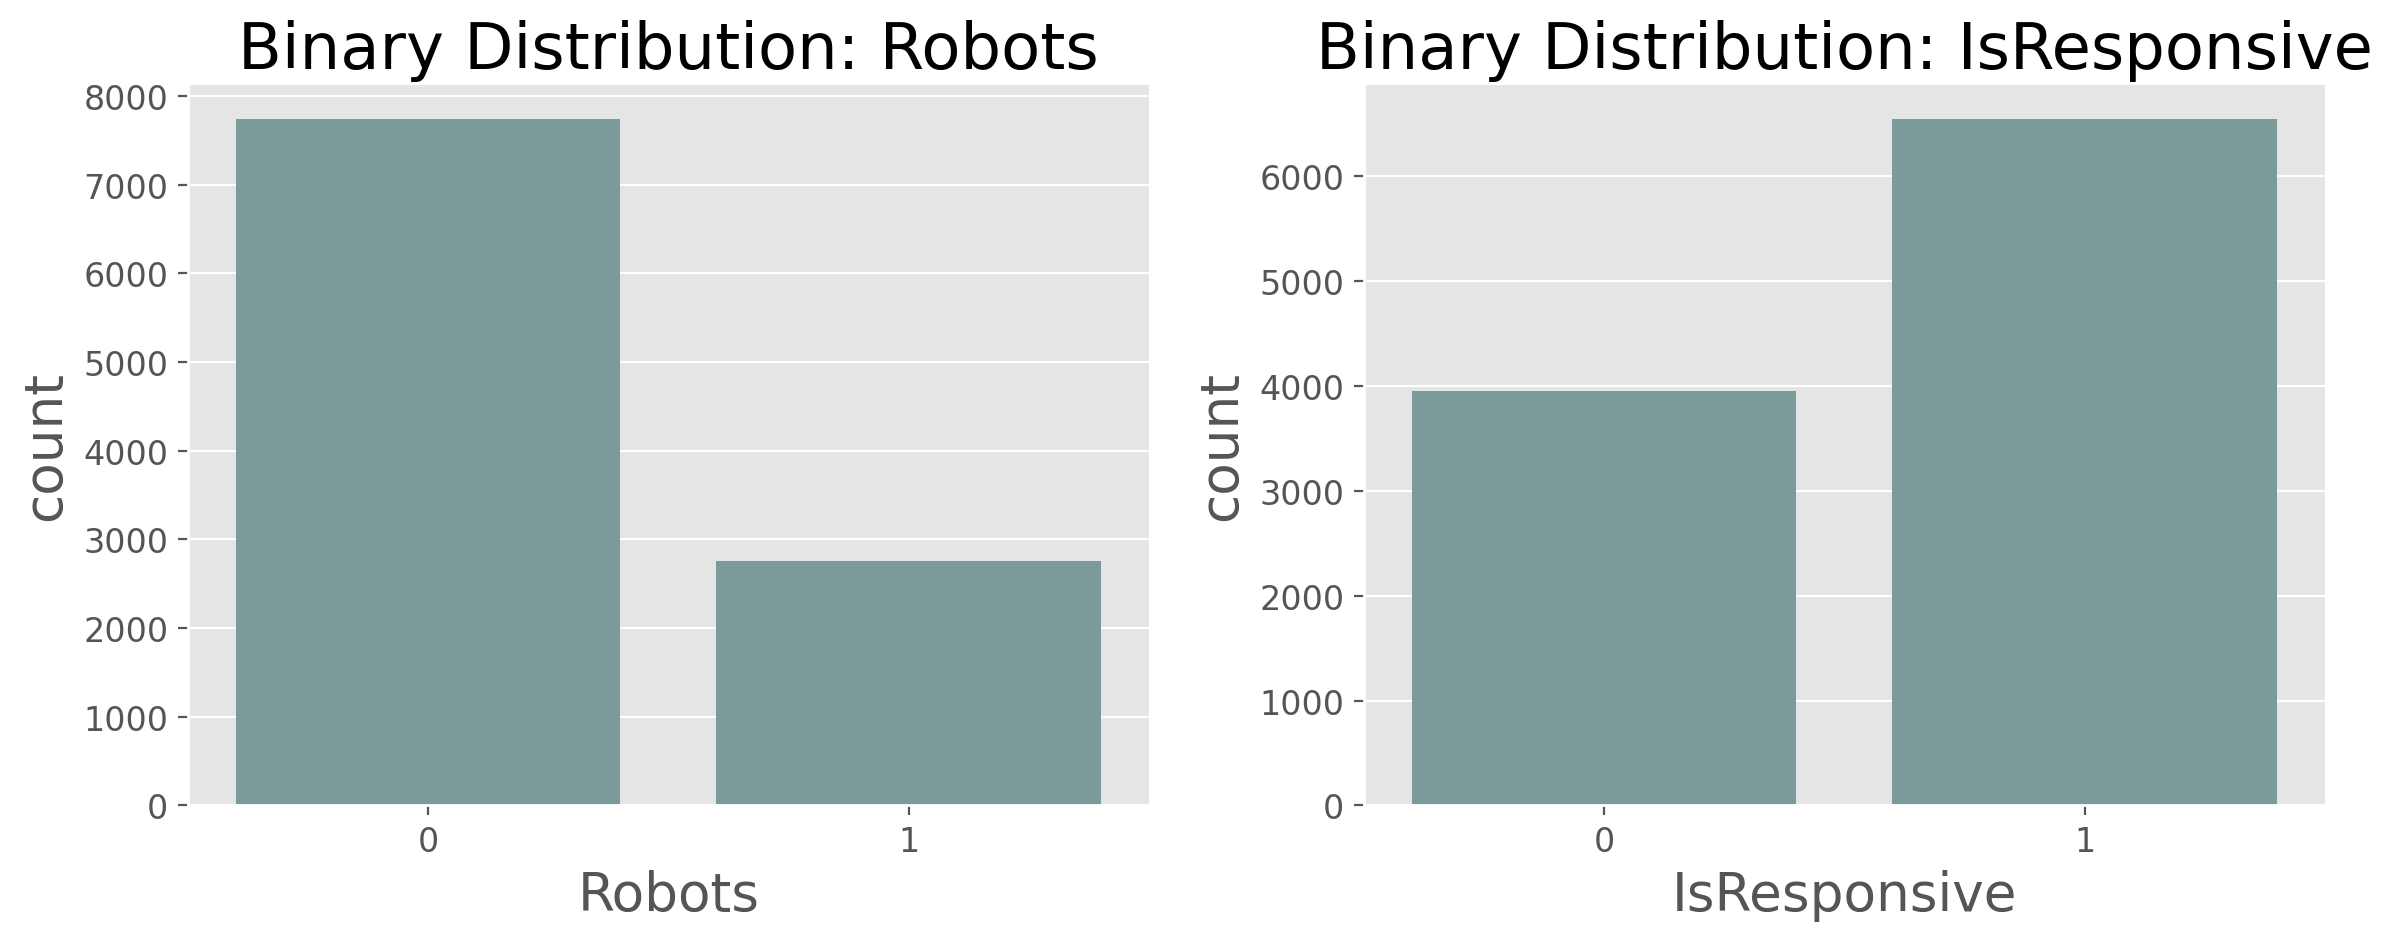

In [43]:
# visualizing binary flags
flag_cols = ['Robots', 'IsResponsive']

plt.figure(figsize=(12, 5))
for i, col in enumerate(flag_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=phishing_df, x=col)
    plt.title(f'Binary Distribution: {col}')
    
    counts = phishing_df[col].value_counts()
    total = len(phishing_df)
    mode_val = counts.idxmax()
    mode_pct = (counts.max() / total) * 100
    
    print(f"The majority of websites in the dataset have a value of {mode_val} for '{col}' ({mode_pct:.1f}%).")

plt.tight_layout()
plt.show()

A robots.txt file defines a website's preferences for bot behavior, instructing crawlers on which pages they should or should not access. In this dataset, approximately 73.7% of the sites lack a robots.txt file. This is a common characteristic of ephemeral infrastructure; these short-lived sites are often designed to avoid detection by automated web crawlers and are not intended for long-term search engine indexing.

Furthermore, a significant majority of the sites are responsive. This optimization allows fraudulent pages to display correctly across a wide range of devices—including mobile and tablets—thereby increasing the potential reach and impact of the phishing campaign.

<Axes: xlabel='LineOfCode', ylabel='Count'>

Text(0.5, 1.0, 'Histogram of LineOfCode')

<Axes: xlabel='LineOfCode'>

Text(0.5, 1.0, 'Boxplot of LineOfCode (Highlighting Outliers)')

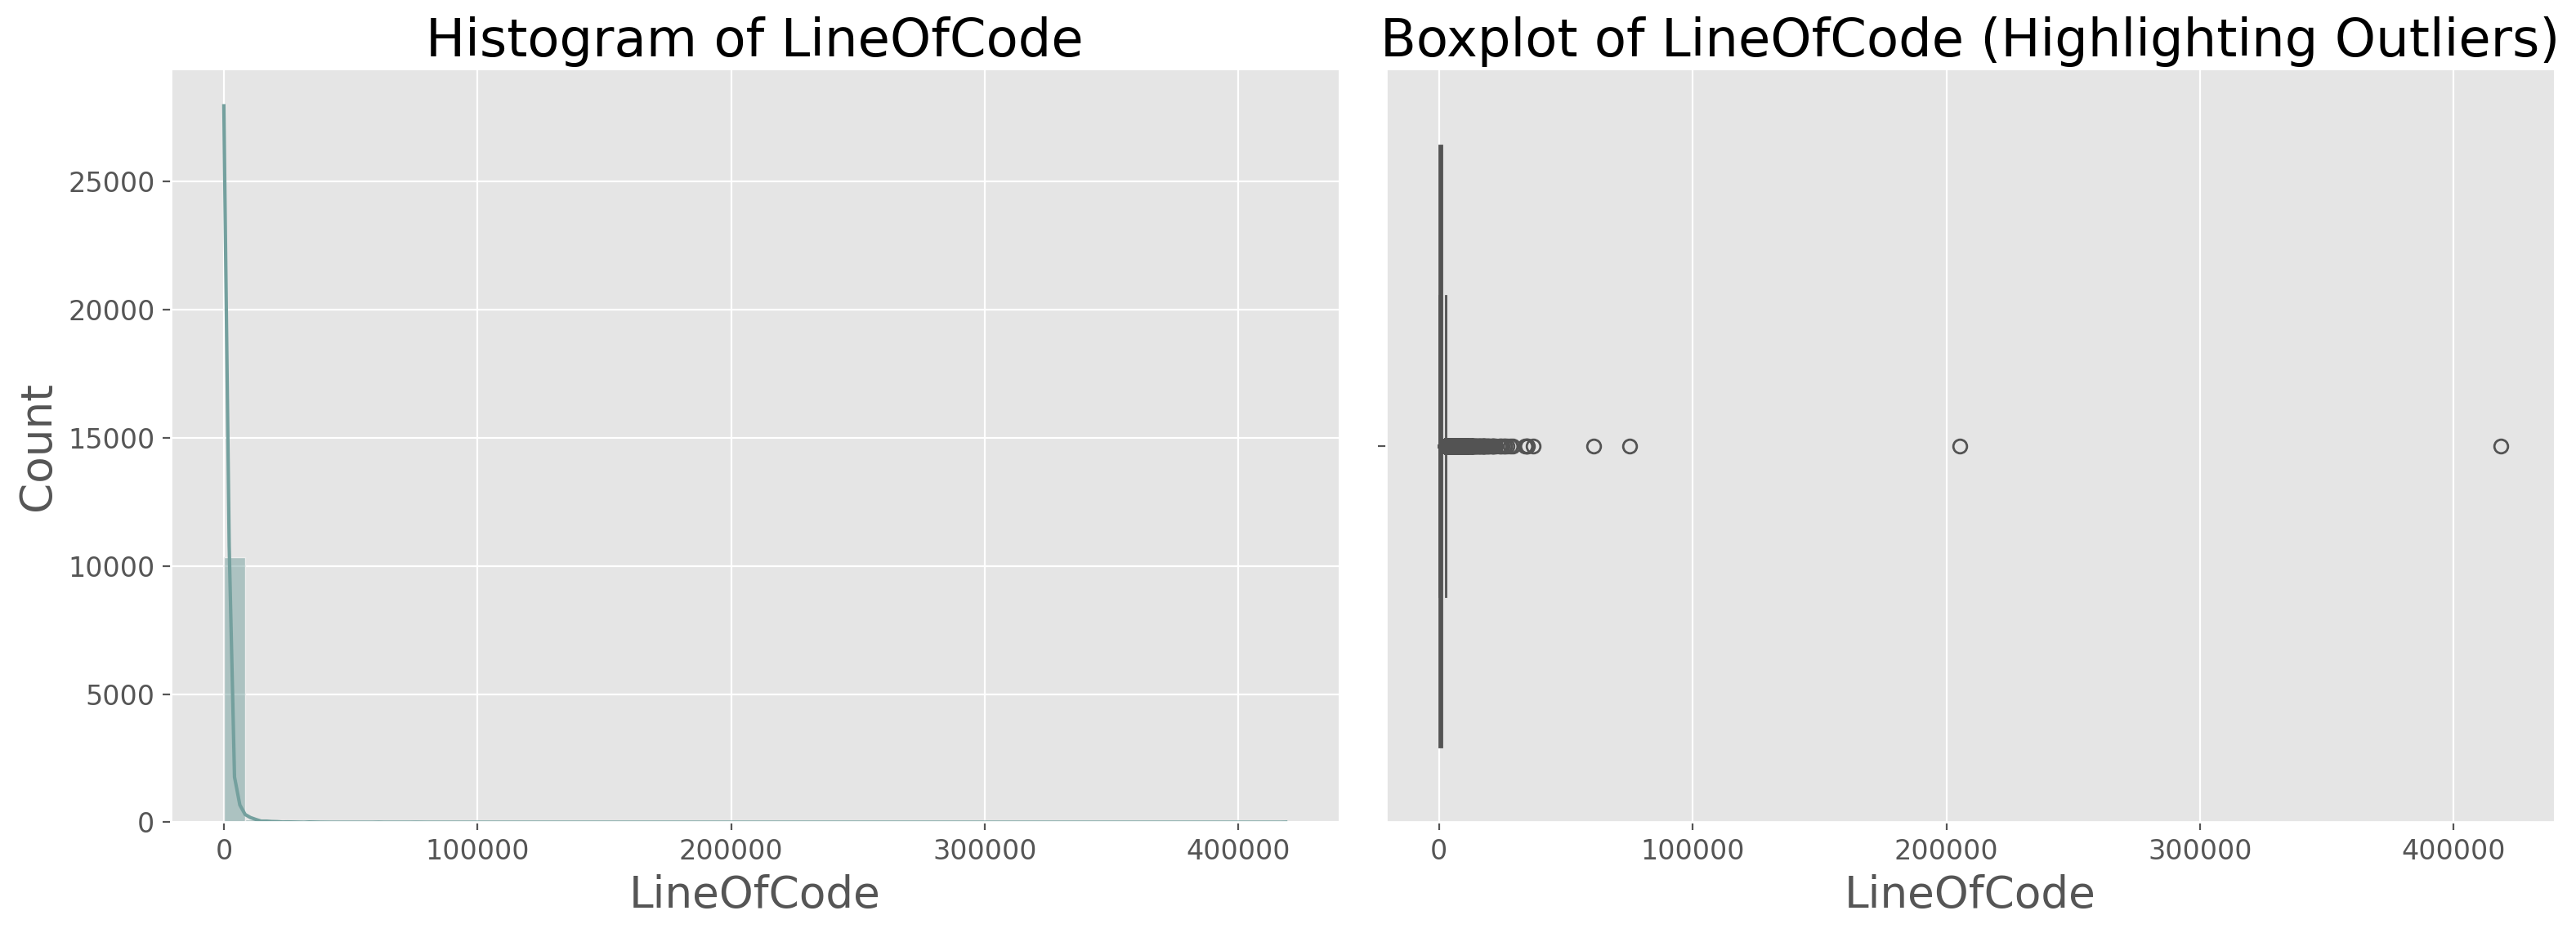

In [35]:
# visualizing the distribution of LineOfCode
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# histogram with KDE
sns.histplot(phishing_df['LineOfCode'], bins=50, kde=True, ax=ax1)
ax1.set_title('Histogram of LineOfCode')

# boxplot to highlight outliers
sns.boxplot(x=phishing_df['LineOfCode'], ax=ax2)
ax2.set_title('Boxplot of LineOfCode (Highlighting Outliers)')

plt.tight_layout()
plt.show()

The histogram and boxplot for LineOfCode show a massive concentration near zero, but with extreme outliers reaching over 400,000. This justifies our earlier step of imputing with the median and also suggests that tree-based models may be appropriate.

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='LineOfCode', ylabel='Count'>

Text(0.5, 1.0, 'Log-Scaled Distribution of LineOfCode')

Text(0.5, 0, 'LineOfCode (Value)')

...

<Axes: >

<Axes: xlabel='NoOfSelfRef', ylabel='Count'>

Text(0.5, 1.0, 'Log-Scaled Distribution of NoOfSelfRef')

Text(0.5, 0, 'NoOfSelfRef (Value)')

Text(0, 0.5, 'Frequency (Log Scale)')

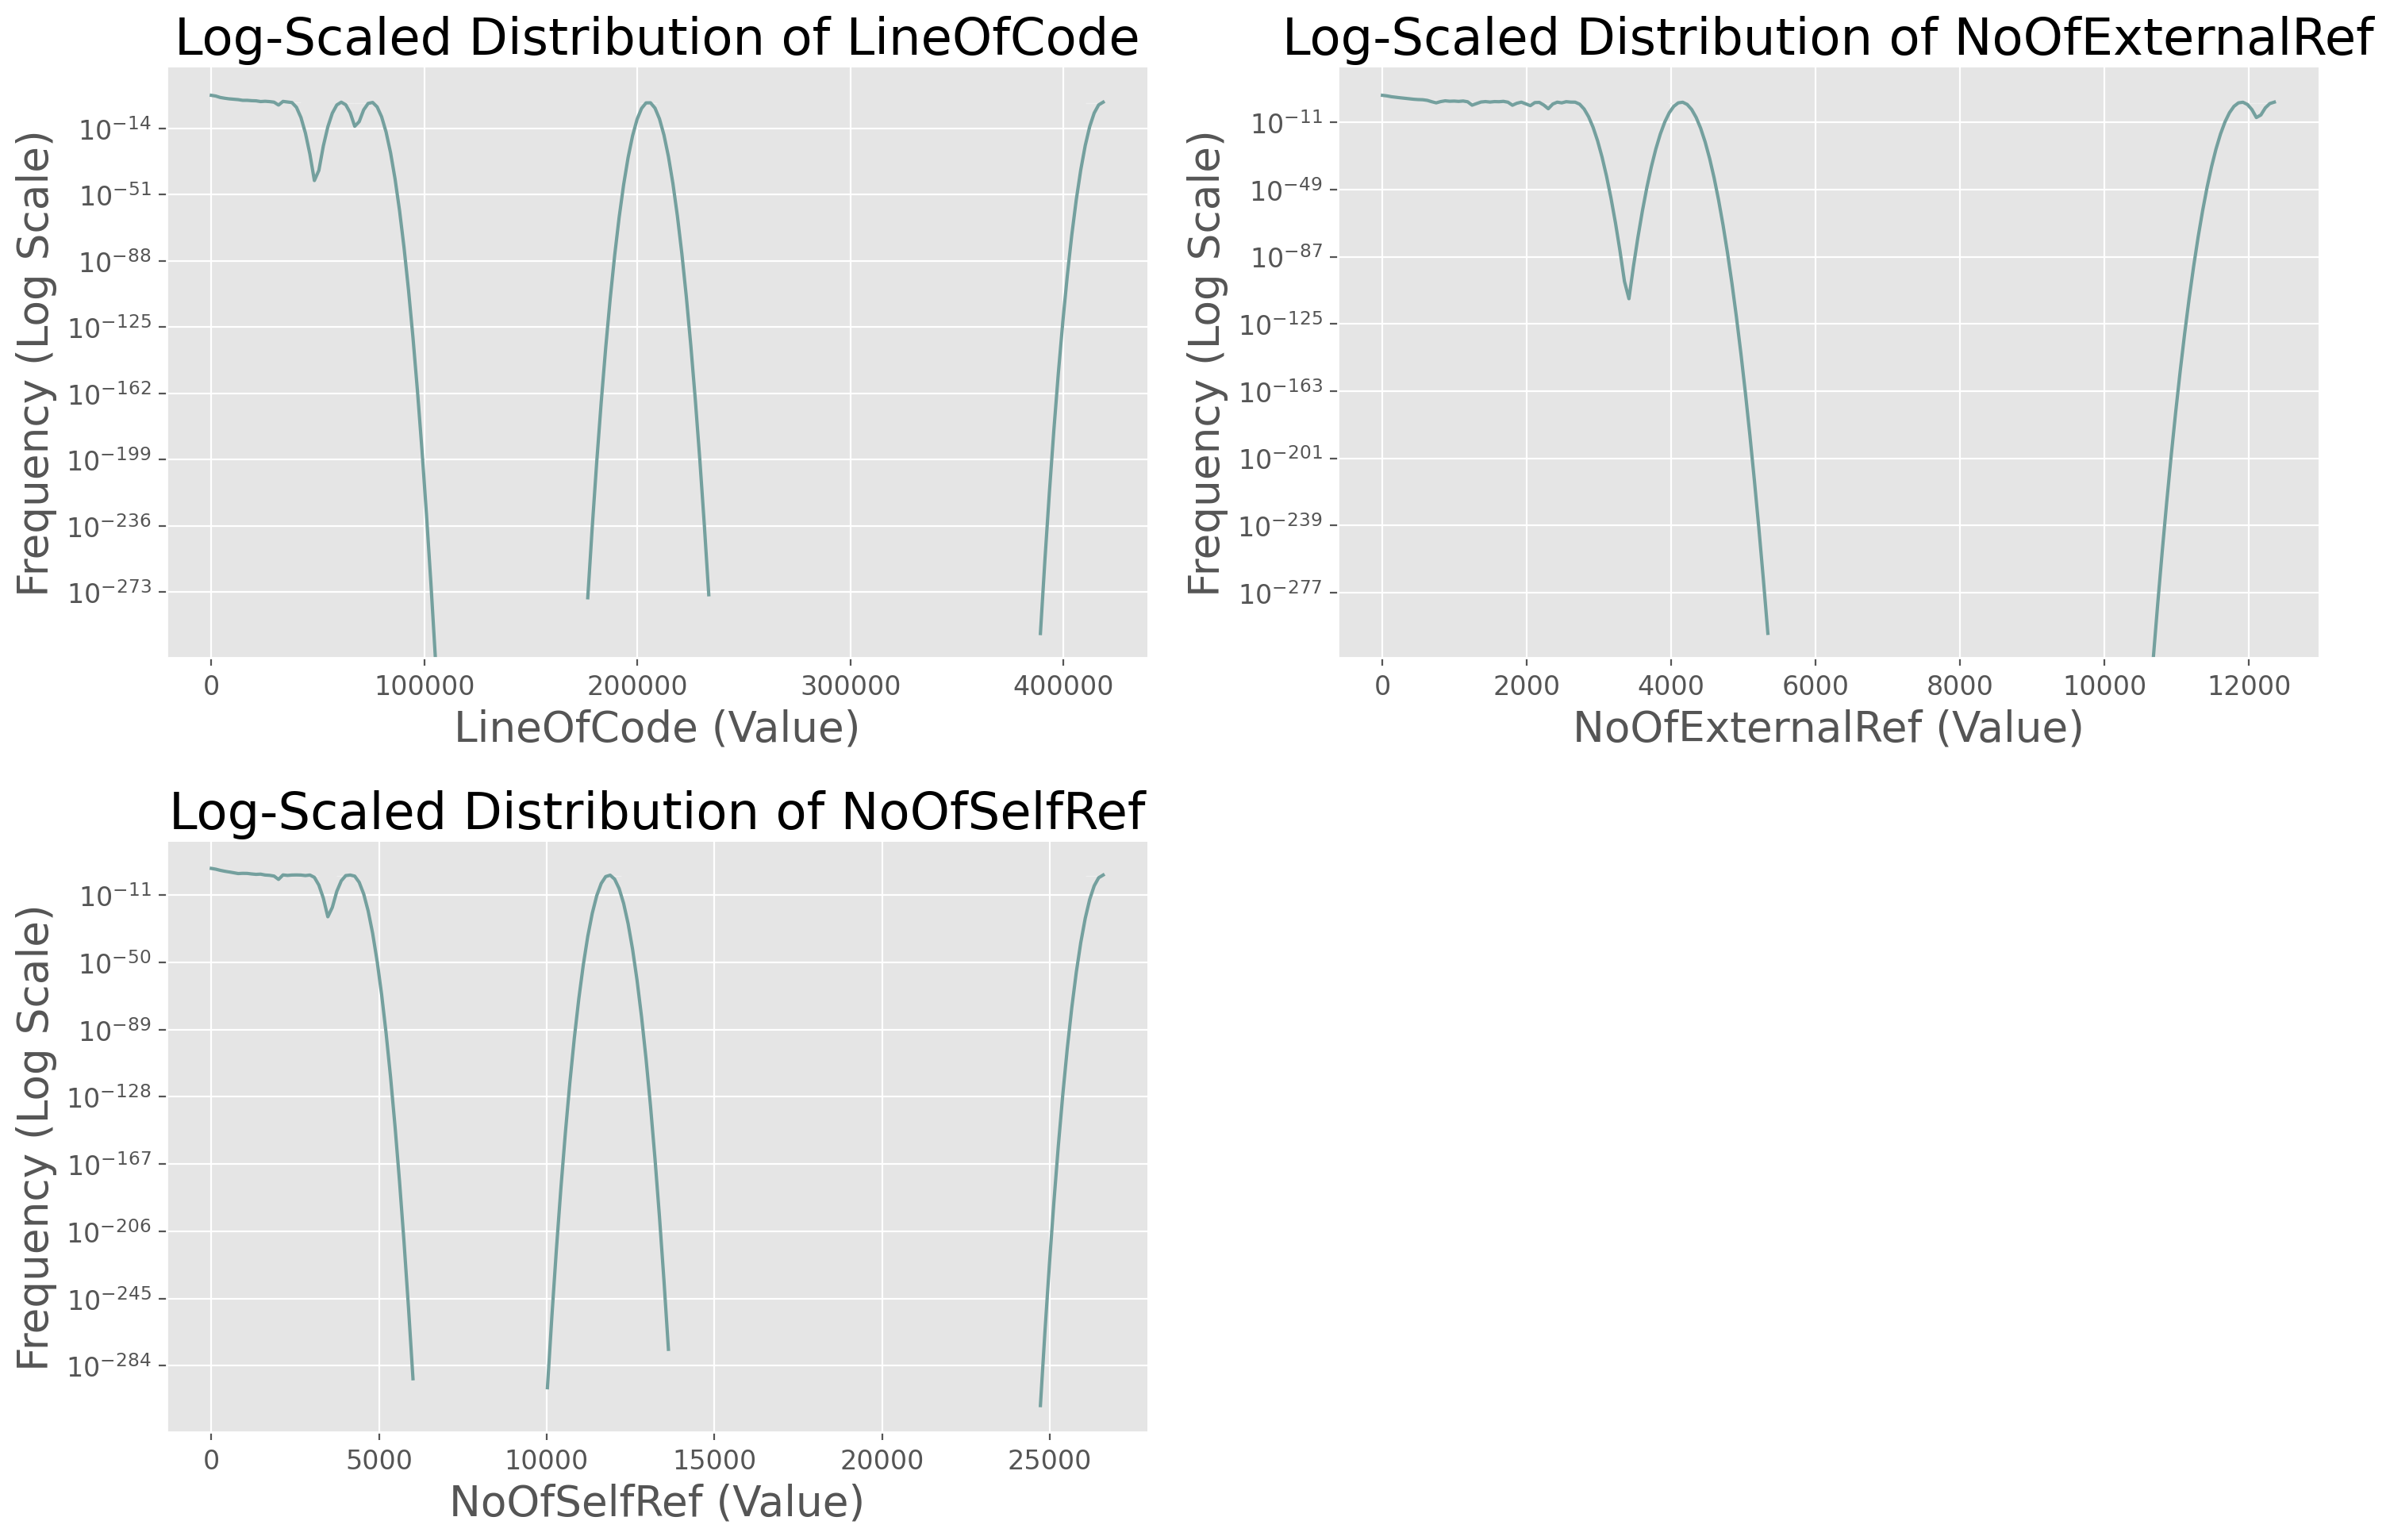

In [36]:
# select features with extreme outliers and skewness
skewed_features = ['LineOfCode', 'NoOfExternalRef', 'NoOfSelfRef']

plt.figure(figsize=(15, 10))
for i, col in enumerate(skewed_features):
    plt.subplot(2, 2, i+1)
    # use log_scale=True to handle the extreme range 
    sns.histplot(phishing_df[col], kde=True, bins=50, log_scale=(False, True))
    plt.title(f'Log-Scaled Distribution of {col}')
    plt.xlabel(f'{col} (Value)')
    plt.ylabel('Frequency (Log Scale)')

plt.tight_layout()
plt.show()

The similar tri-modal shapes of LineOfCode and NoOfSelfRef indicate a very high correlation. This suggests that as the complexity of a site’s code increases, the number of internal (self) references tends to scale proportionally.

<Figure size 1500x1000 with 0 Axes>

<Axes: >

<Axes: xlabel='NoOfImage', ylabel='Count'>

Text(0.5, 1.0, 'Univariate: NoOfImage')

<Axes: >

...

<Axes: xlabel='NoOfiFrame', ylabel='Count'>

Text(0.5, 1.0, 'Univariate: NoOfiFrame')

<Axes: >

<Axes: xlabel='DomainAgeMonths', ylabel='Count'>

Text(0.5, 1.0, 'Univariate: DomainAgeMonths')

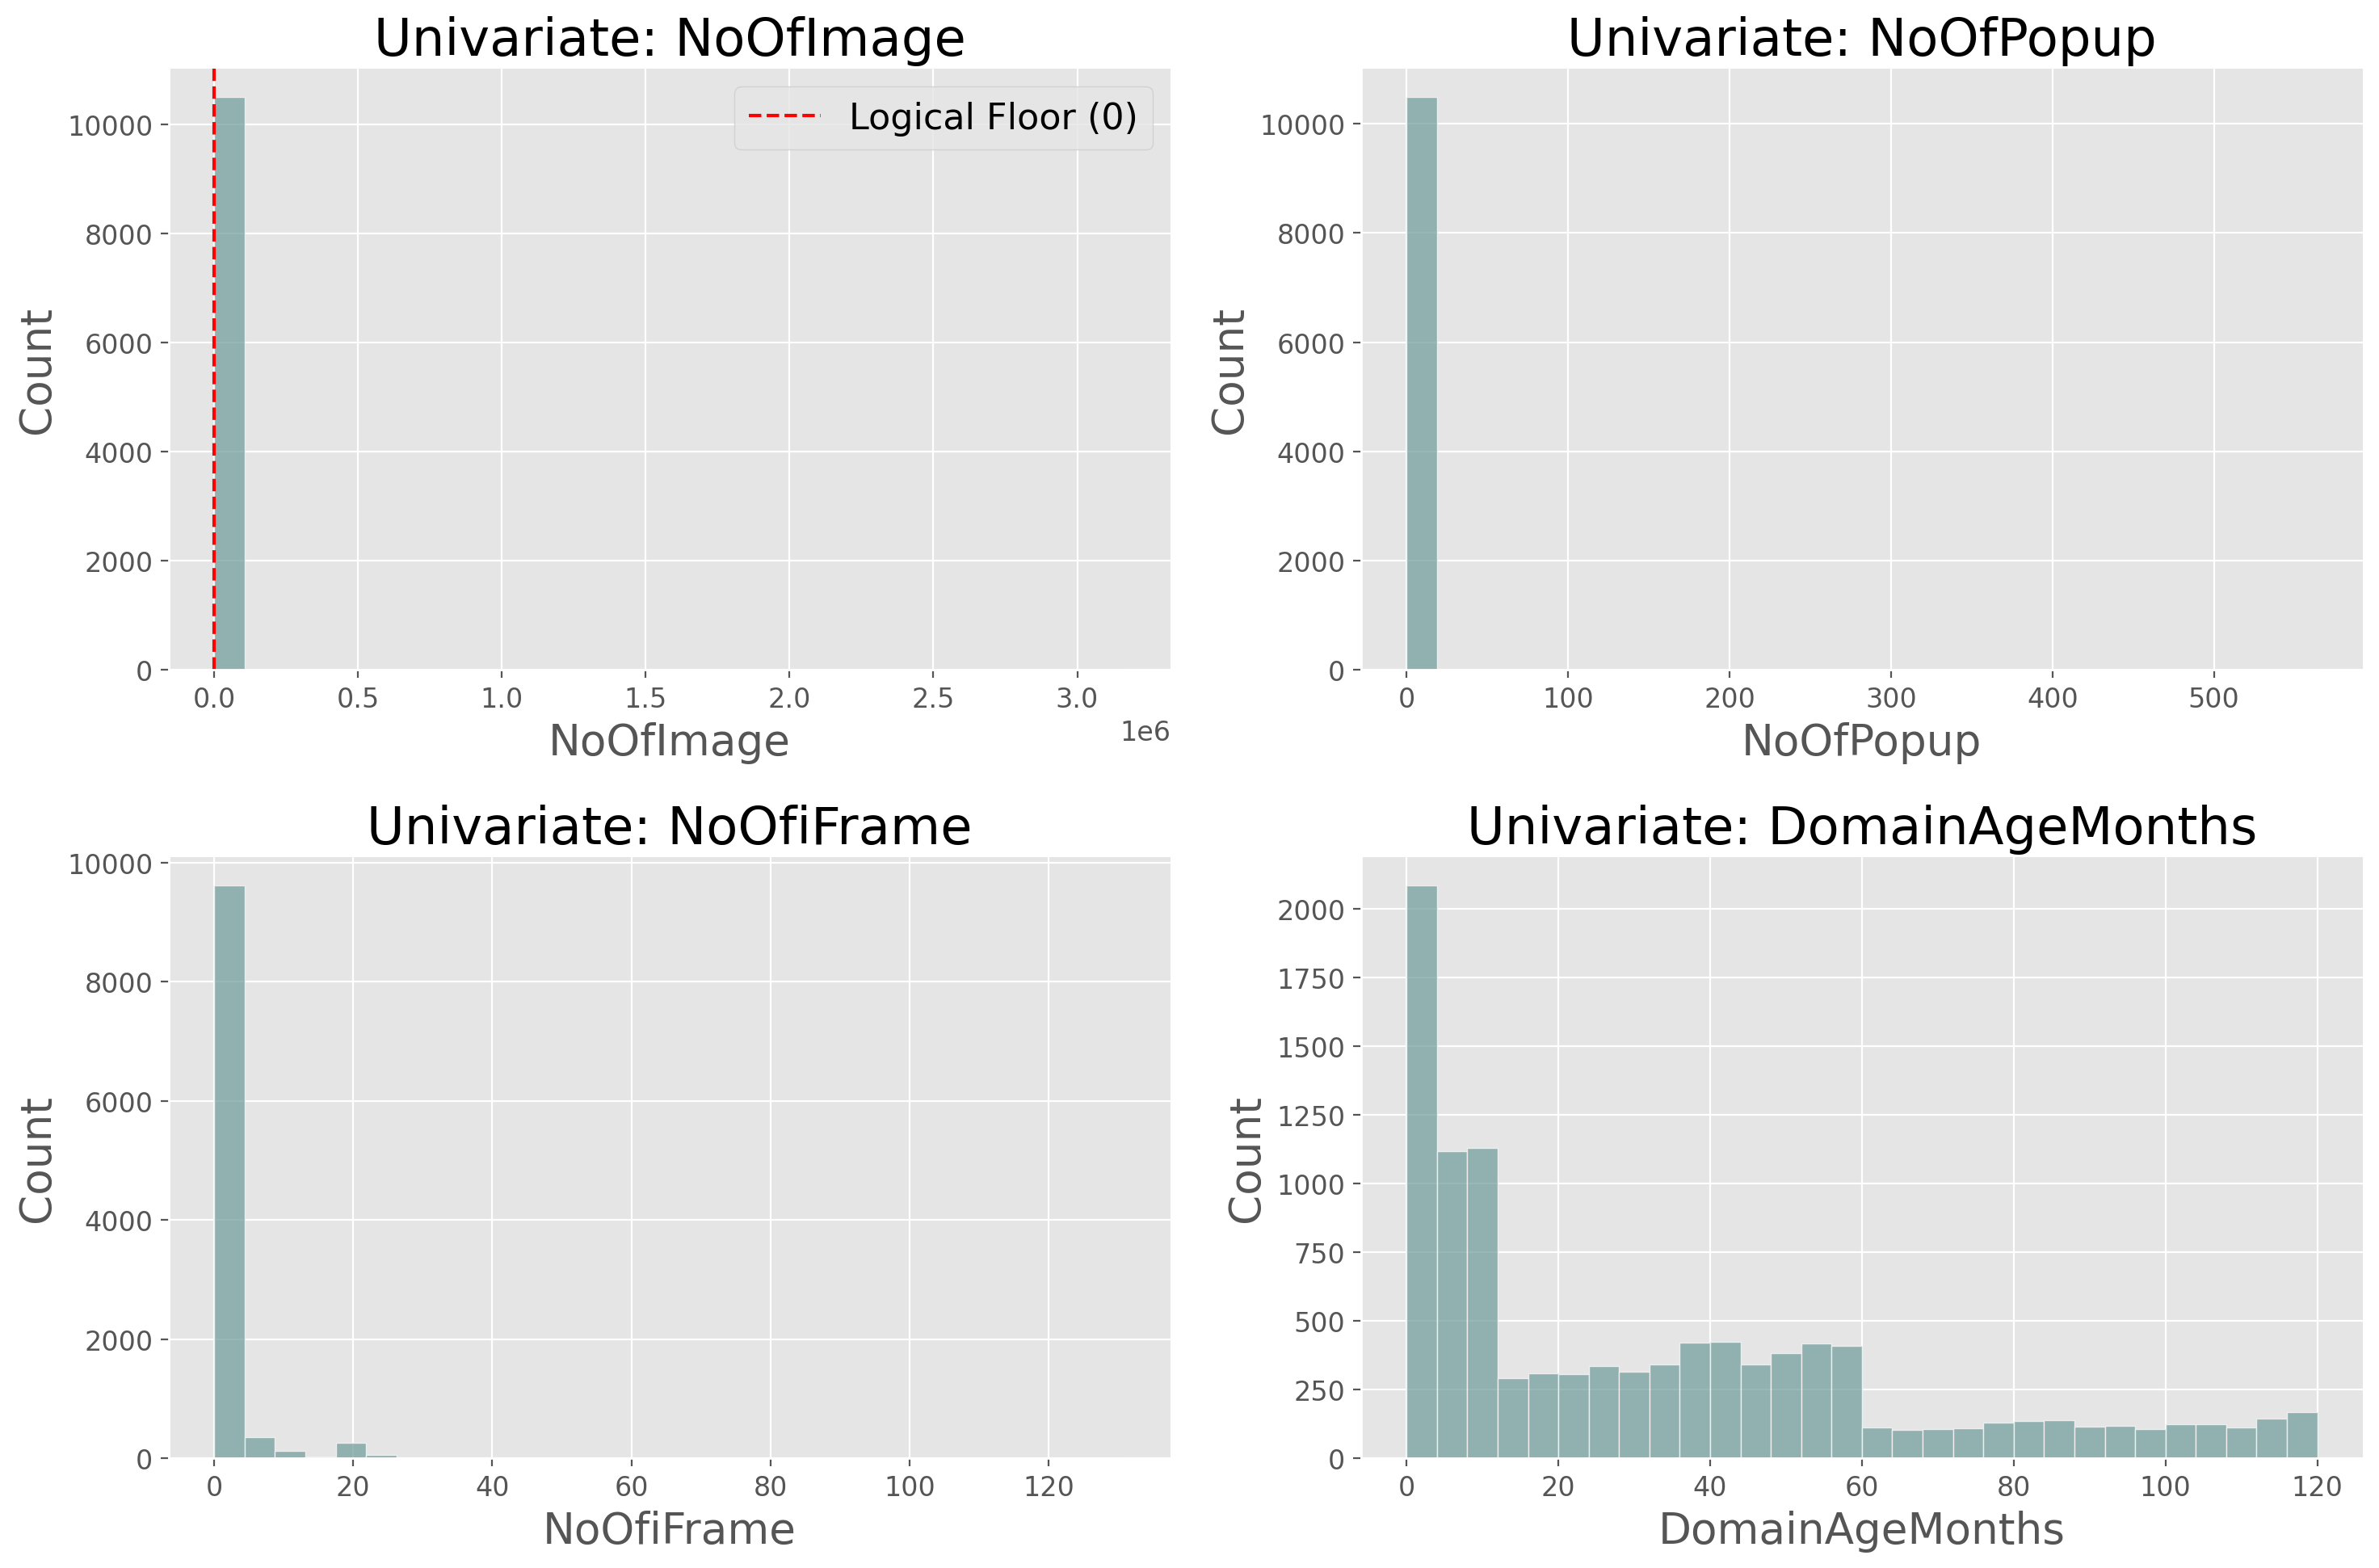

In [37]:
# visualizing impossible negative values and zero-heavy features
zero_heavy = ['NoOfImage', 'NoOfPopup', 'NoOfiFrame', 'DomainAgeMonths']

plt.figure(figsize=(15, 10))
for i, col in enumerate(zero_heavy):
    plt.subplot(2, 2, i+1)
    sns.histplot(phishing_df[col], bins=30, kde=False)
    plt.title(f'Univariate: {col}')
    
    # highlight the logical contamination in NoOfImage
    if col == 'NoOfImage':
        plt.axvline(0, color='red', linestyle='--', label='Logical Floor (0)')
        plt.legend()

plt.tight_layout()
plt.show()

We see that DomainAgeMonths is left-skewed (0-10 months), which aligns with our earlier theory that phishing campaigns often use temporary infrastructure (burner domains). As the age increases, the frequency drops significantly, with very few domains reaching the 120-month (10-year) mark.

# 4. Bivariate Exploration

<Figure size 1200x600 with 0 Axes>

<Axes: ylabel='Industry'>

Text(0.5, 1.0, 'Phishing Rate by Industry')

Text(0.5, 0, 'Proportion of Phishing Sites (Label=1)')

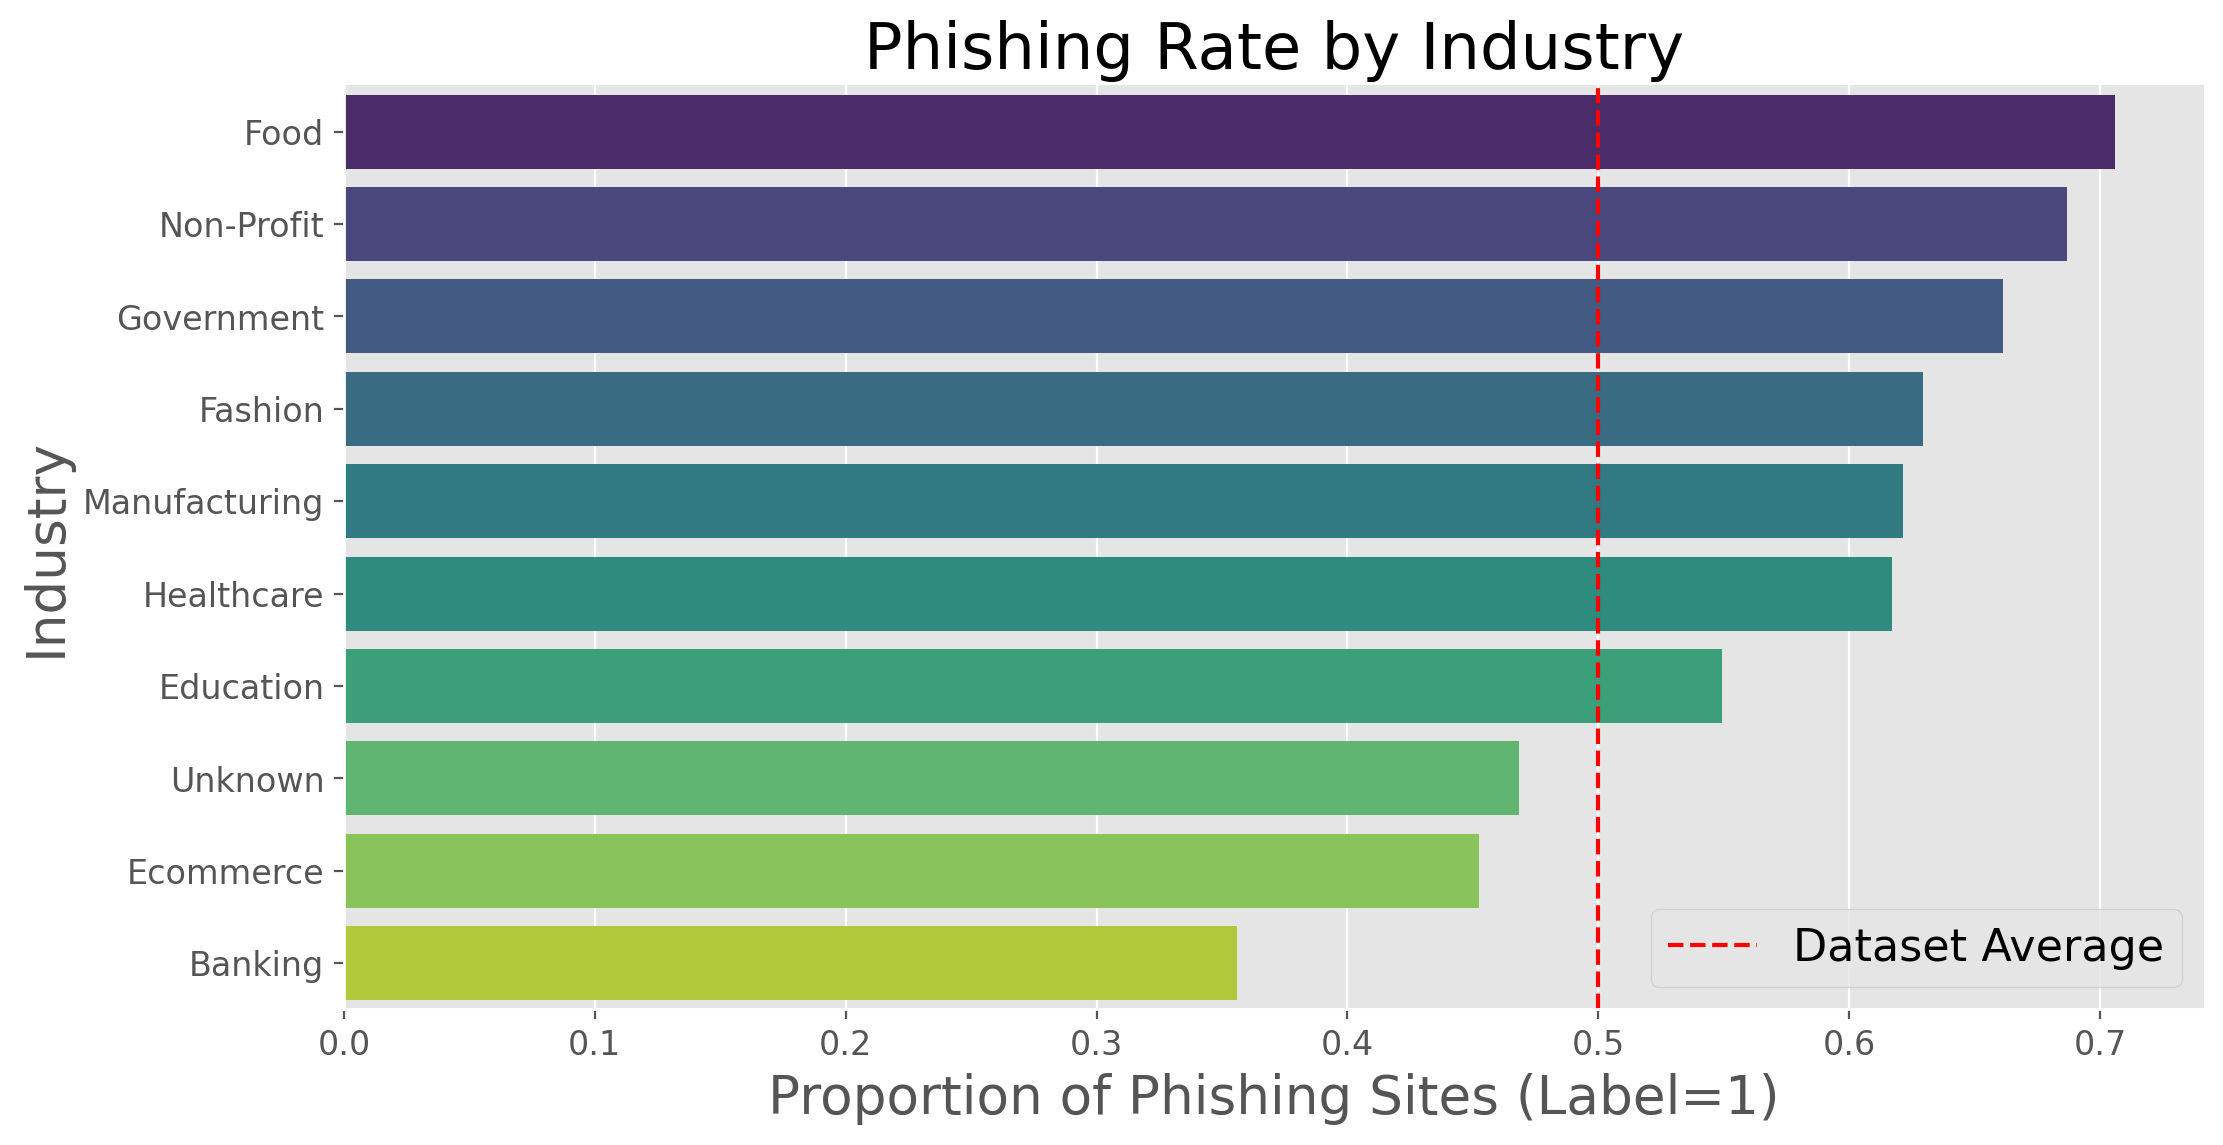

The 'Food' category has the highest phishing concentration at 70.6%.


<Figure size 1200x600 with 0 Axes>

<Axes: ylabel='HostingProvider'>

Text(0.5, 1.0, 'Phishing Rate by HostingProvider')

Text(0.5, 0, 'Proportion of Phishing Sites (Label=1)')

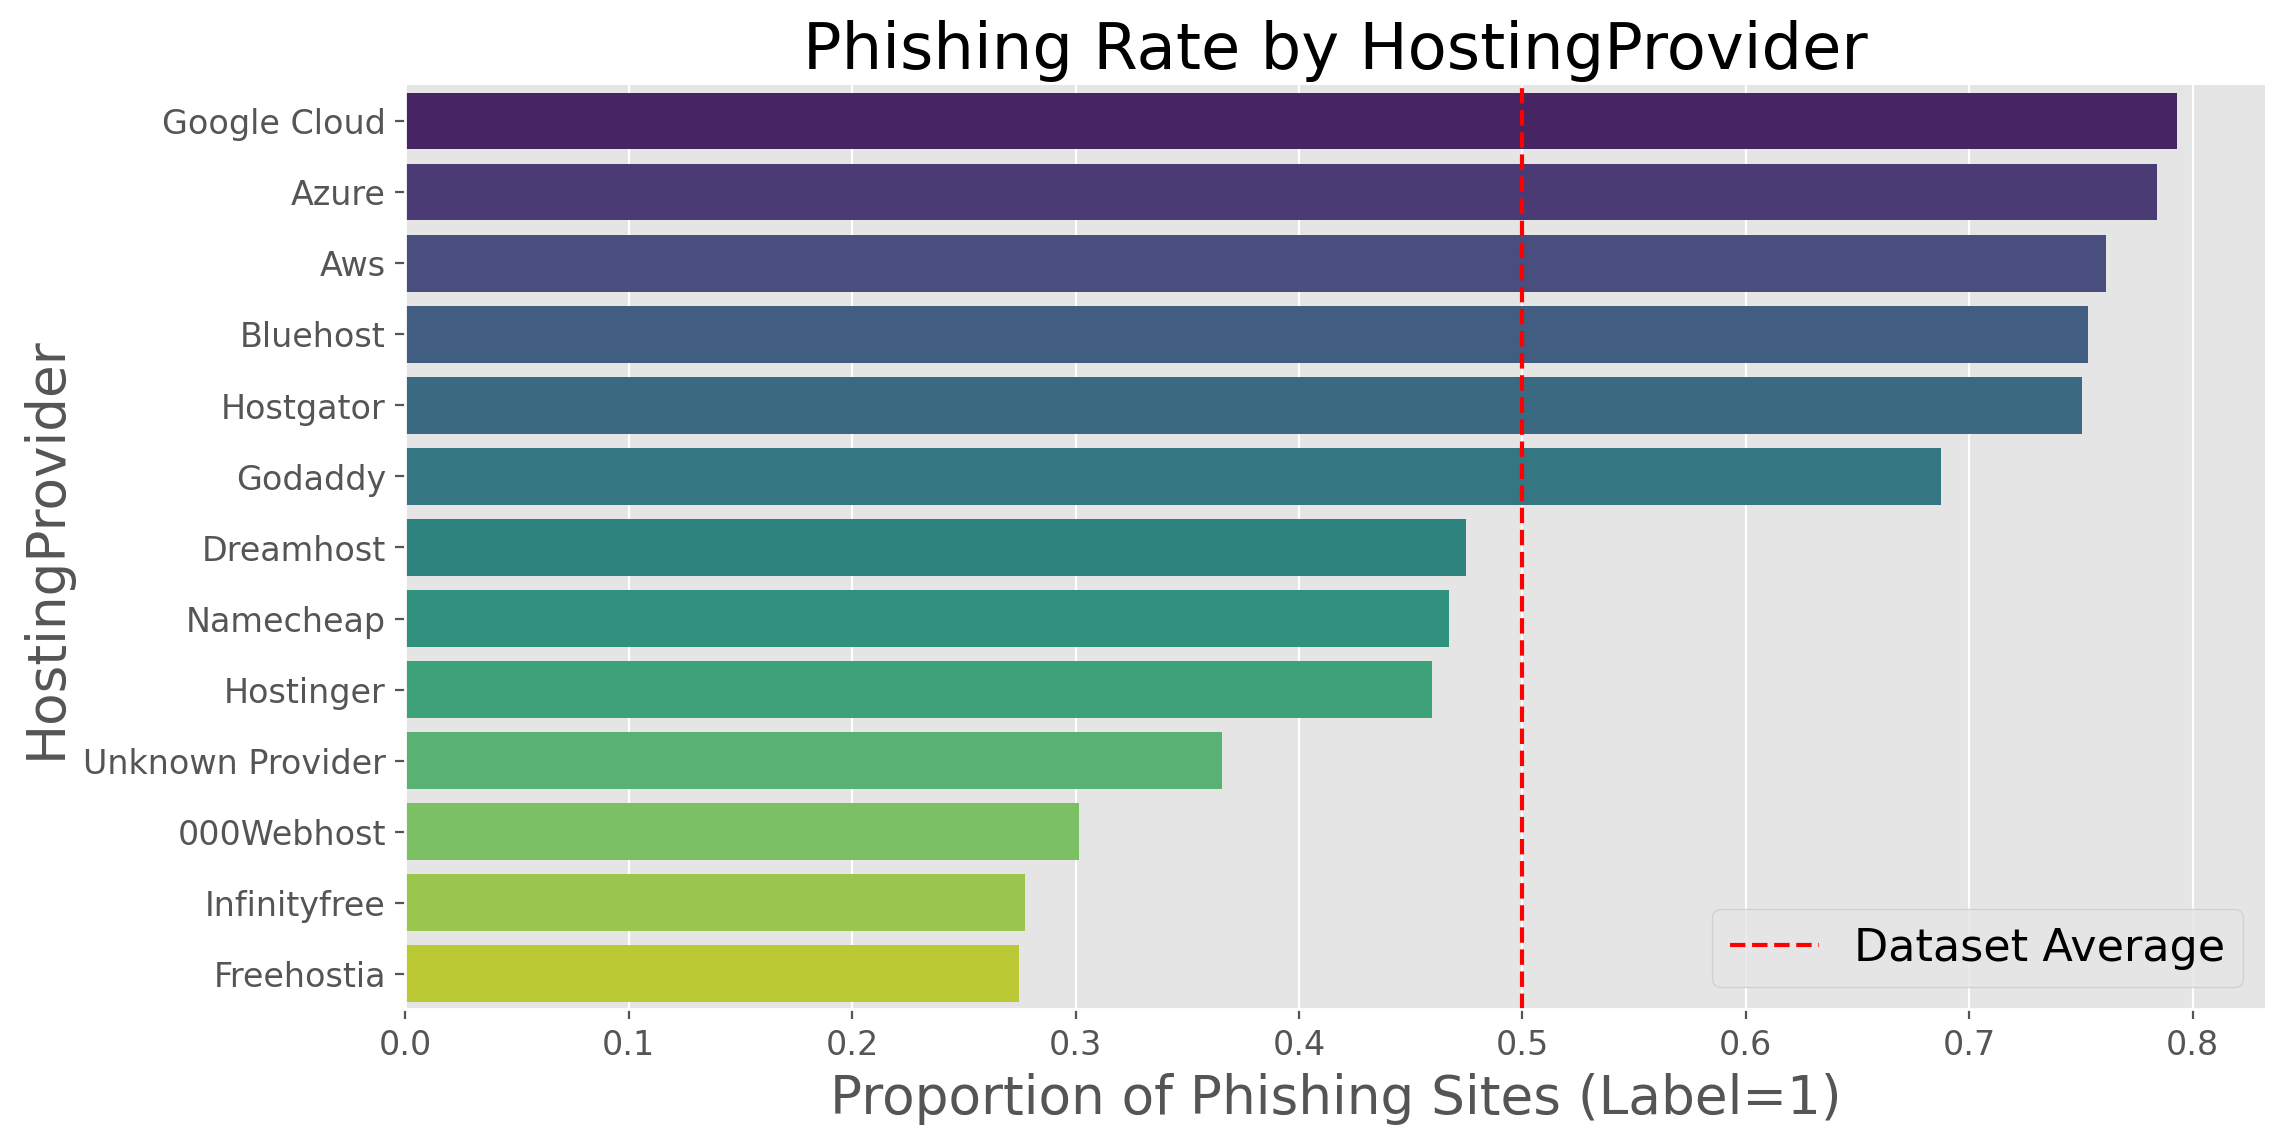

The 'Google Cloud' category has the highest phishing concentration at 79.3%.


In [51]:
# analyzing the relationship between Categories and the Label
cat_to_analyze = ['Industry', 'HostingProvider']

for col in cat_to_analyze:
    plt.figure(figsize=(12, 6))
    relation = phishing_df.groupby(col)['label'].mean().sort_values(ascending=False)
    
    sns.barplot(x=relation.values, y=relation.index, palette='viridis')
    plt.axvline(0.5, color='red', linestyle='--', label='Dataset Average')
    plt.title(f'Phishing Rate by {col}')
    plt.xlabel('Proportion of Phishing Sites (Label=1)')
    plt.legend()
    plt.show()

    top_phish_cat = relation.index[0]
    top_phish_rate = relation.values[0] * 100
    print(f"The '{top_phish_cat}' category has the highest phishing concentration at {top_phish_rate:.1f}%.")


Earlier, we had observed that eCommerce and Unknown Providers are the most frequent categories, representing the bulk of the data samples. However, when analyzing the Phishing Rate, it turned out that Food and Google Cloud carry the highest risk density. This suggests that while while high-transaction industries like eCommerce are common targets, niche or high-trust sectors like Food and Government are more likely to be fraudulent in this sample.
We had also previously observed a high occurrence of "Unknown Providers", however, we now discover that the providers with the highest phishing rates are on Google Cloud, Azure and AWS (~75-80%), with phishing proportions far exceeding the dataset average. This suggests that attackers in this dataset are successfully leveraging high-trust, reputable infrastructure to host their campaigns, likely to bypass security filters that might otherwise flag "Unknown" or low-cost hosts.

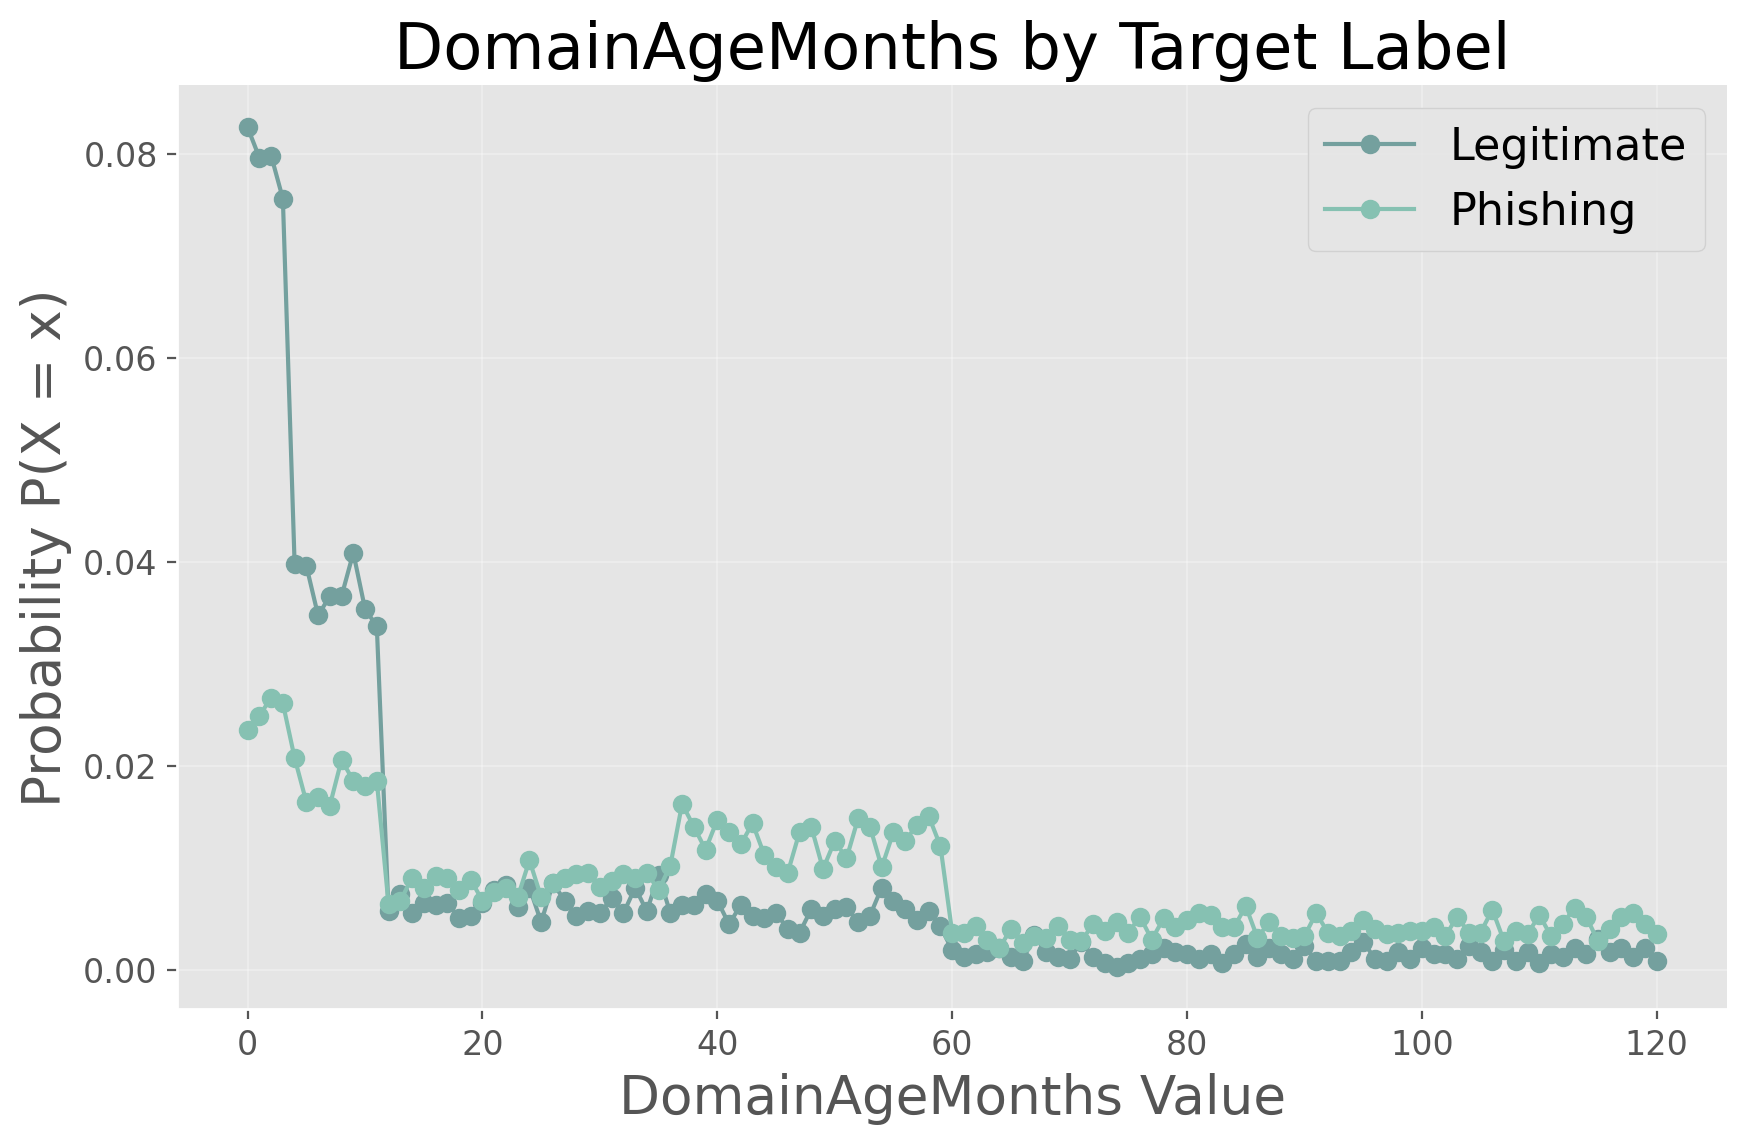

In [56]:
def plot_bivariate_pmf(df, feature):
    plt.figure(figsize=(10, 6))
    
    # calculate PMF for each class
    for label in [0, 1]:
        subset = df[df['label'] == label][feature]
        pmf = subset.value_counts(normalize=True).sort_index()
        
        label_text = "Phishing" if label == 1 else "Legitimate"
        plt.plot(pmf.index, pmf.values, marker='o', linestyle='-', label=label_text)

    plt.title(f'{feature} by Target Label')
    plt.xlabel(f'{feature} Value')
    plt.ylabel('Probability P(X = x)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_bivariate_pmf(phishing_df, 'DomainAgeMonths')

Looking at the PMF for the phishing label, we observe concentrated bursts of phishing activity in two distinct regions. Beyond what we found earlier that newer domains tend to have higher frequency counts, we observe that there is also a high probability of legitimate sites for this time frame. Hence, focusing on this initial period might be an insufficient predictor. Instead, between 35-60 months, there is a second broader spike, where the probability of a site being phishing is higher than it's probability of it being legitimate by a significant margin. The attackers in this dataset could be purchasing expired domains that already have a few years of history, which tend to have higher trust scores to bypass reputation filters that automatically flag brand-new sites.

# 5. Multivariate Exploration

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Feature Correlation Heatmap')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5]),
 [Text(0.5, 0, 'LineOfCode'),
  Text(1.5, 0, 'LargestLineLength'),
  Text(2.5, 0, 'NoOfURLRedirect'),
  Text(3.5, 0, 'NoOfSelfRedirect'),
  Text(4.5, 0, 'NoOfPopup'),
  Text(5.5, 0, 'NoOfiFrame'),
  Text(6.5, 0, 'NoOfImage'),
  Text(7.5, 0, 'NoOfSelfRef'),
  Text(8.5, 0, 'NoOfExternalRef'),
  Text(9.5, 0, 'Robots'),
  Text(10.5, 0, 'IsResponsive'),
  Text(11.5, 0, 'DomainAgeMonths'),
  Text(12.5, 0, 'label')])

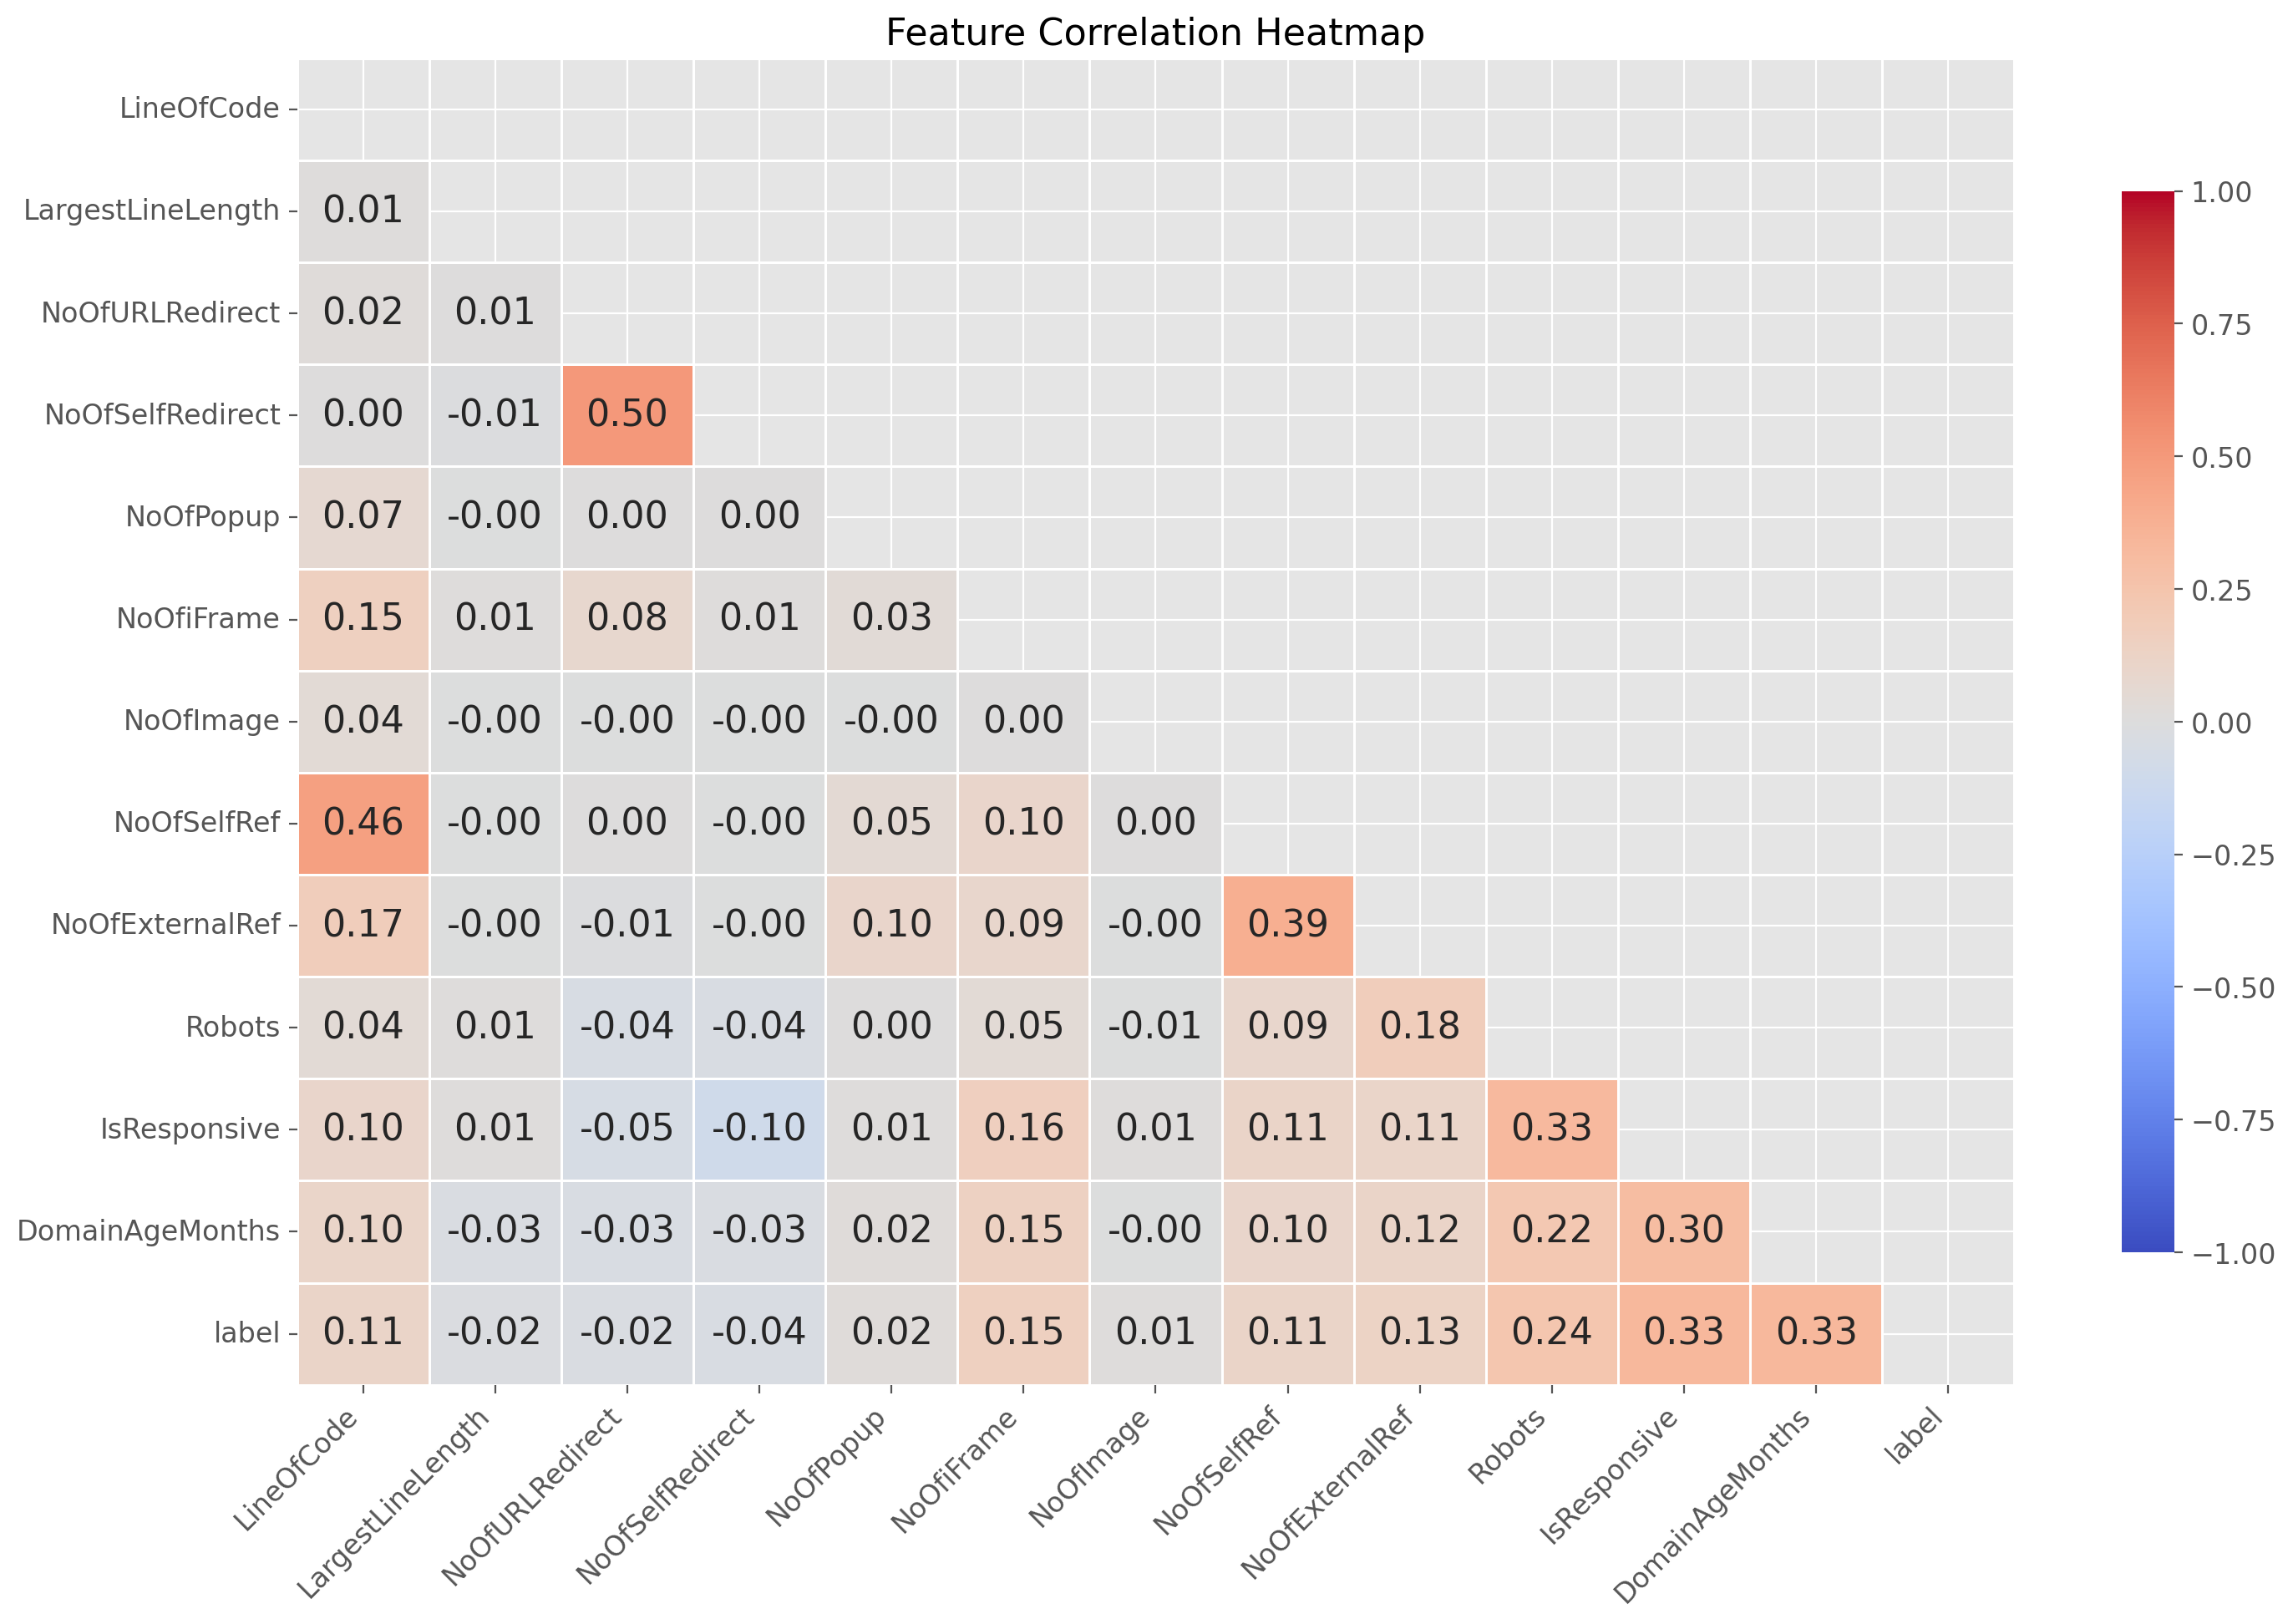

Features with High Redundancy (r > 0.85):
Series([], dtype: float64)


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numerical columns for the correlation matrix
numerical_df = phishing_df.select_dtypes(include=[np.number])

# 2. Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# 3. Create the heatmap plot
plt.figure(figsize=(15, 10))

# Create a mask to hide the upper triangle (since it's a mirror of the lower)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,          # Show the correlation numbers
    fmt=".2f",           # Format to 2 decimal places
    cmap='coolwarm',     # Red for positive, Blue for negative
    vmin=-1, vmax=1,     # Ensure the scale is always -1 to 1
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Identification of Redundant Features (Multicollinearity)
print("Features with High Redundancy (r > 0.85):")
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.85) & (high_corr < 1)]
print(high_corr)

Top Predictors: IsResponsive (0.33) and DomainAgeMonths (0.33) show the strongest positive correlations with the label, confirming they are high-value features for detecting phishing.

Secondary Signals: Robots (0.24), NoOfIFrame (0.15), and NoOfExternalRef (0.13) also show notable positive correlations, meaning their presence or higher counts often coincide with phishing.

The Correlation Heatmap confirms that there is no significant multicollinearity in the dataset, as all feature pairings fall well below the 0.85 redundancy threshold. The highest correlation observed is a moderate 0.50 between redirect types. This independence suggests that the selected features provide diverse signals, which should allow our models to capture complex, non-linear patterns without being skewed by redundant data.

# 6. Brief Conclusion

Summary of Key Findings

    Targeted Industries: While eCommerce is the most frequent category, Food and Non-profit sectors exhibit significantly higher risk densities, suggesting attackers prefer niche or high-trust targets.

    Infrastructure Strategy: Phishing campaigns are increasingly leveraging reputable cloud services like Google Cloud and Azure (with ~80% phishing rates) rather than just unknown or low-cost hosting.

    Aged Domain Tactic: The discovery of a "danger zone" between 35–60 months in the bivariate PMF indicates that attackers utilize aged domains to bypass reputation-based security filters.

    Feature Integrity: The multivariate analysis confirms that features are relatively independent, with no correlations exceeding the 0.85 redundancy threshold, which validates the use of all selected numerical features for the ensemble models.